# Segment-Grass Experiment: Ghost Rate & Drop Rate Sweep

**Goal**: Systematically study how ghost hits (fake detector noise) and dropped hits (detector inefficiency) interact with the geometric-clipping "segment grass" effect identified in the occupancy distributions.

**Sweep grid**:
- `ghost_rate`: [0.0, 0.05, 0.10, 0.15, 0.20, 0.30]
- `drop_rate`: [0.0, 0.05, 0.10, 0.15, 0.20, 0.30]
- `angle`: [±0.2, ±0.1] rad (±0.2 shows grass, ±0.1 is the control)
- `n_tracks`: [20, 50, 100]

**Total**: 6 × 6 × 2 × 3 = **216 jobs** (10 events each, run via Condor)

**Pipeline**:
1. `submit.sh` → generates params + submits to Condor
2. Workers run `scripts/run_worker.py` per grid point
3. `scripts/aggregate.py` merges results
4. This notebook loads and visualises the aggregated data

In [39]:
# ── Imports & configuration ──────────────────────────────────────
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import PercentFormatter

%matplotlib inline
plt.rcParams["figure.dpi"] = 140
plt.rcParams.update({
    "font.size": 11, "axes.labelsize": 12, "axes.titlesize": 12,
    "xtick.labelsize": 10, "ytick.labelsize": 10, "legend.fontsize": 9,
    "axes.linewidth": 1.0, "lines.linewidth": 1.8, "font.family": "serif",
})

RESULTS_DIR = Path("results")
AGG_DIR = RESULTS_DIR / "aggregated"
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

def save_fig(fig, name):
    fig.savefig(FIG_DIR / f"{name}.pdf", bbox_inches="tight")
    fig.savefig(FIG_DIR / f"{name}.png", bbox_inches="tight")

print(f"Results dir: {RESULTS_DIR.resolve()}")
print(f"Figures dir: {FIG_DIR.resolve()}")

Results dir: /data/bfys/gscriven/Quantum_Track_Reconstruction/Toy_Characterisation/Segment_Grass/results
Figures dir: /data/bfys/gscriven/Quantum_Track_Reconstruction/Toy_Characterisation/Segment_Grass/figures


In [40]:
# ── Load aggregated data ─────────────────────────────────────────
with open(AGG_DIR / "sweep_flat.json") as f:
    rows = json.load(f)

df = pd.DataFrame(rows)
print(f"Loaded {len(df)} grid points")
print(f"\nColumns: {list(df.columns)}")
print(f"\nSweep ranges:")
print(f"  angle:      {sorted(df['angle'].unique())}")
print(f"  n_tracks:   {sorted(df['n_tracks'].unique())}")
print(f"  ghost_rate: {sorted(df['ghost_rate'].unique())}")
print(f"  drop_rate:  {sorted(df['drop_rate'].unique())}")
df.head()

Loaded 216 grid points

Columns: ['angle', 'n_tracks', 'ghost_rate', 'drop_rate', 'occ_mean', 'occ_std', 'n_anomalous_occ', 'frac_anomalous_occ', 'mean_n_clipped', 'mean_n_ghost_hits', 'mean_n_dropped', 'mean_n_segments', 'efficiency', 'efficiency_std', 'reco_ghost_rate', 'reco_ghost_rate_std', 'clone_fraction', 'mean_true_activation', 'mean_false_activation', 'hits_mod0_mean', 'hits_mod1_mean', 'hits_mod2_mean', 'hits_mod3_mean', 'hits_mod4_mean']

Sweep ranges:
  angle:      [np.float64(0.1), np.float64(0.2)]
  n_tracks:   [np.int64(20), np.int64(50), np.int64(100)]
  ghost_rate: [np.float64(0.0), np.float64(0.05), np.float64(0.1), np.float64(0.15), np.float64(0.2), np.float64(0.3)]
  drop_rate:  [np.float64(0.0), np.float64(0.05), np.float64(0.1), np.float64(0.15), np.float64(0.2), np.float64(0.3)]


,angle,n_tracks,ghost_rate,drop_rate,occ_mean,occ_std,n_anomalous_occ,frac_anomalous_occ,mean_n_clipped,mean_n_ghost_hits,...,reco_ghost_rate,reco_ghost_rate_std,clone_fraction,mean_true_activation,mean_false_activation,hits_mod0_mean,hits_mod1_mean,hits_mod2_mean,hits_mod3_mean,hits_mod4_mean
0,0.2,20,0.0,0.00,31.943605,9.690520,40,0.040282,0.7,0.0,...,0.0,0.0,0.0,1.085905,0.400000,20.0,20.0,20.0,20.0,19.3
1,0.2,20,0.0,0.05,29.769737,9.213456,804,0.881579,2.8,0.0,...,0.0,0.0,0.0,1.020760,0.400000,19.1,19.2,18.8,17.6,16.5
2,0.2,20,0.0,0.10,28.525481,8.769231,883,1.000000,1.7,0.0,...,0.0,0.0,0.0,0.983958,0.400000,18.2,17.8,18.1,17.7,16.5
3,0.2,20,0.0,0.15,27.054632,8.115517,826,0.980998,1.2,0.0,...,0.0,0.0,0.0,0.942503,0.400049,17.0,17.0,16.4,17.6,16.2
4,0.2,20,0.0,0.20,25.059585,7.748413,772,1.000000,2.5,0.0,...,0.0,0.0,0.0,0.881492,0.400000,15.6,15.8,16.0,15.5,14.3


## Section 0 — Occupancy Histograms (Reproducing the Original Observation)

These histograms reproduce the occupancy distributions from the hit-competition study that first revealed the "segment grass" effect. Each histogram shows how many candidate segments use a given hit. For $n$ tracks, internal hits should appear at occupancy $2n$ and boundary hits at $n$. Any counts outside these expected peaks are **anomalous** — the segment grass.

We compare the **clean baseline** (ghost = 0%, drop = 0%) against selected noisy configurations to show how ghost and drop rates modify the distribution.

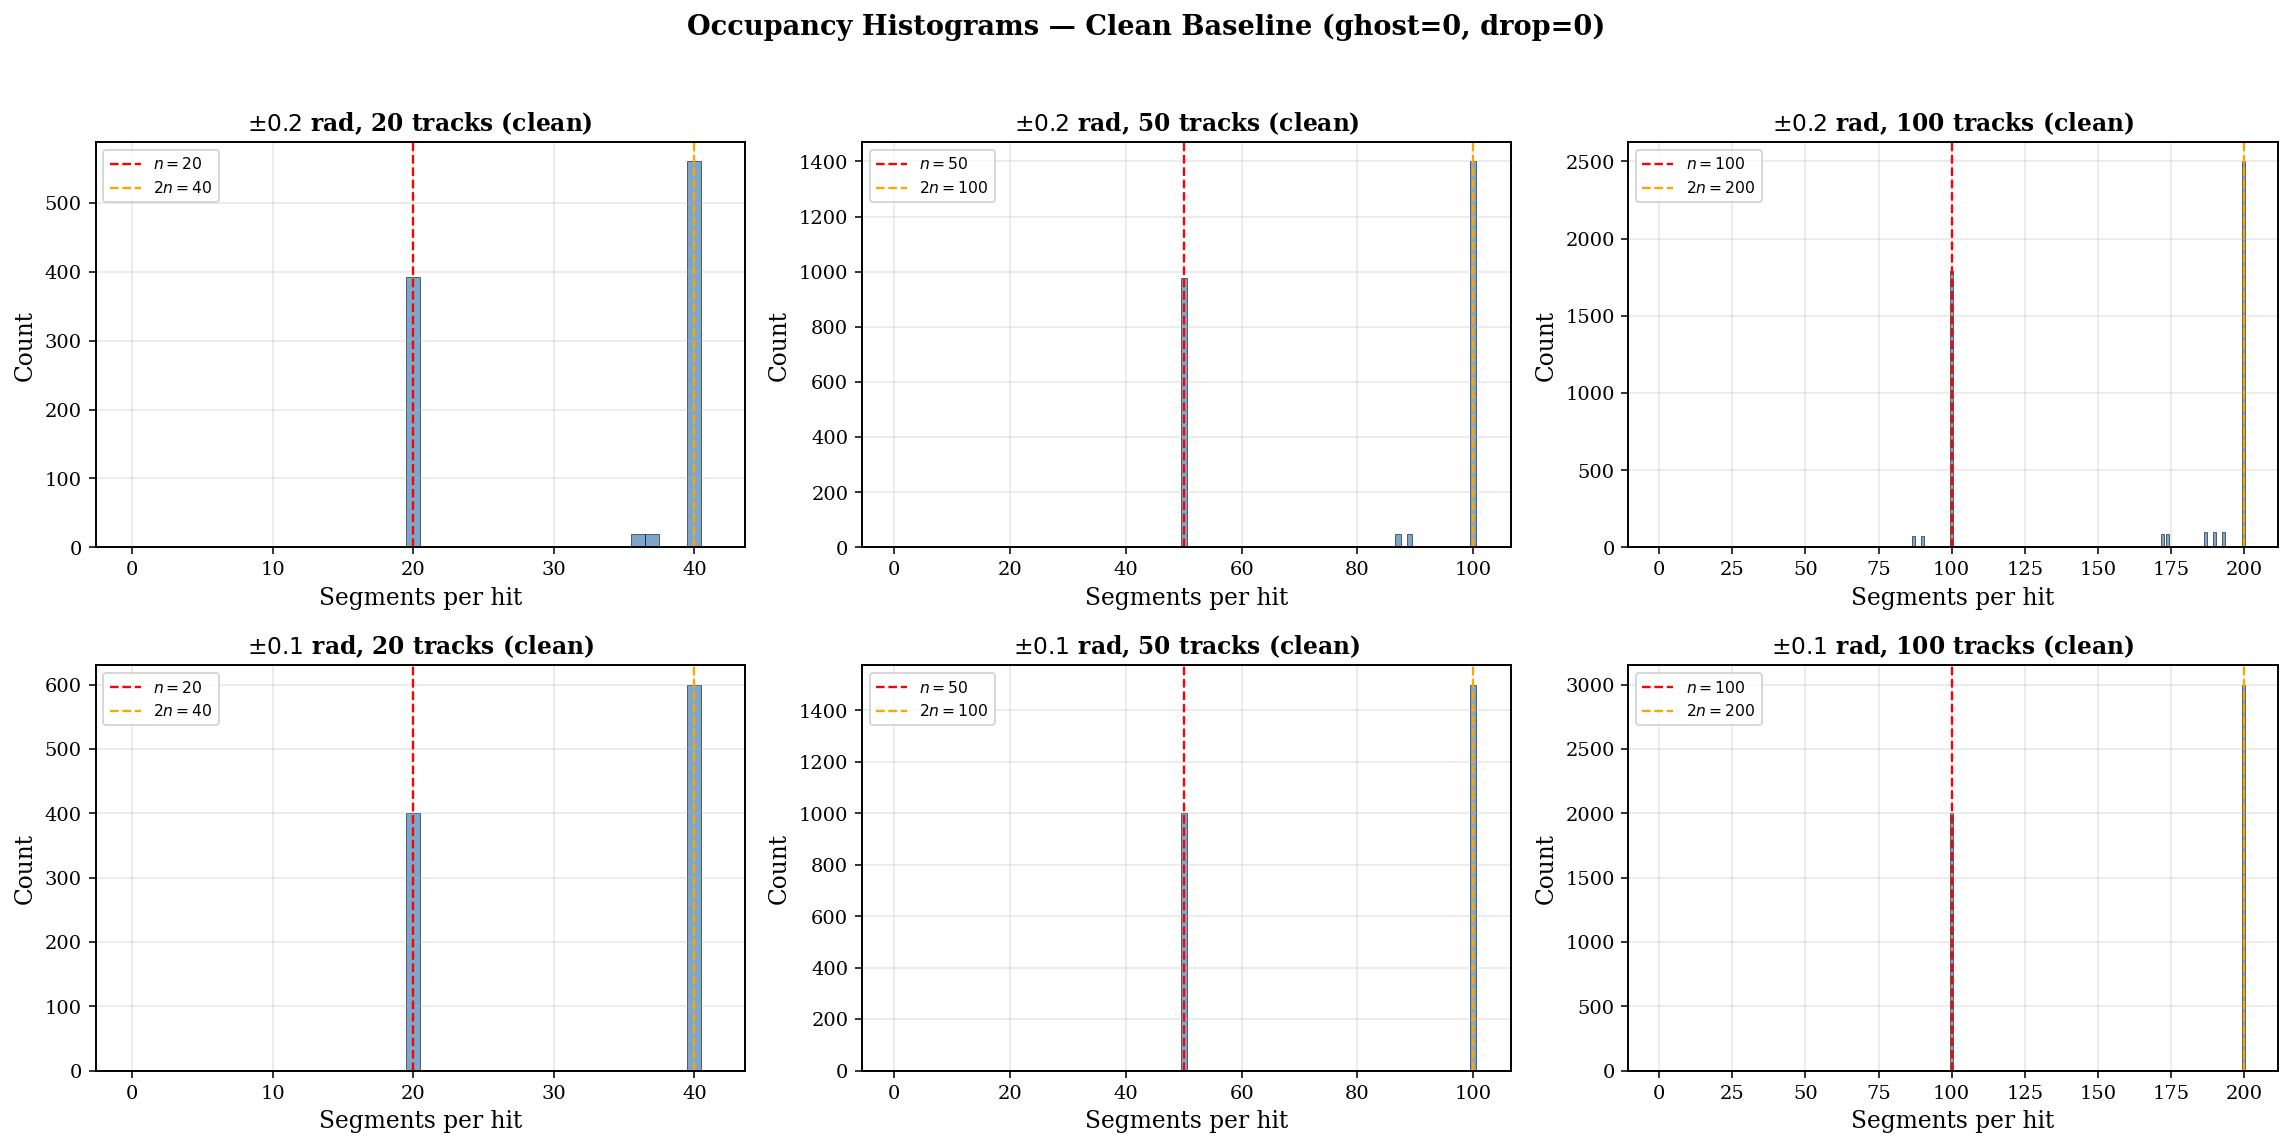

In [41]:
# ── Load raw occupancy arrays from per-job .npz files ────────────
import glob

def load_occ_for_params(angle, n_tracks, ghost_rate, drop_rate):
    """Load the raw occupancy array for a specific parameter combination."""
    params_dir = RESULTS_DIR / "params"
    for pf in sorted(params_dir.glob("job_*.json")):
        with open(pf) as f:
            p = json.load(f)
        if (p["angle"] == angle and p["n_tracks"] == n_tracks
                and p["ghost_rate"] == ghost_rate
                and p["drop_rate"] == drop_rate):
            job_name = pf.stem
            npz_path = RESULTS_DIR / job_name / "arrays.npz"
            if npz_path.exists():
                d = np.load(npz_path)
                return d["occ_all"]
    return None

# ── (a) Clean baseline histograms: rows=angles, cols=track counts ─
fig, axes = plt.subplots(len(angles), len(track_counts),
                         figsize=(5.5 * len(track_counts),
                                  4 * len(angles)),
                         squeeze=False)

for row, angle in enumerate(angles):
    for col, n_trk in enumerate(track_counts):
        ax = axes[row][col]
        occ = load_occ_for_params(angle, n_trk, 0.0, 0.0)
        if occ is not None:
            hi = int(np.max(occ)) + 2
            bins = np.arange(0, hi + 1) - 0.5
            ax.hist(occ, bins=bins, alpha=0.7,
                    color="steelblue", edgecolor="black", lw=0.4)
            # Mark expected peaks
            ax.axvline(n_trk, color="red", ls="--", lw=1.2,
                       label=f"$n={n_trk}$")
            ax.axvline(2 * n_trk, color="orange", ls="--", lw=1.2,
                       label=f"$2n={2*n_trk}$")
            ax.legend(fontsize=8)
        ax.set_xlabel("Segments per hit")
        ax.set_ylabel("Count")
        ax.set_title(f"$\\pm{angle}$ rad, {n_trk} tracks (clean)",
                     fontweight="bold")
        ax.grid(True, alpha=0.3)

plt.suptitle("Occupancy Histograms — Clean Baseline (ghost=0, drop=0)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
save_fig(fig, "occ_hist_clean")
plt.show()

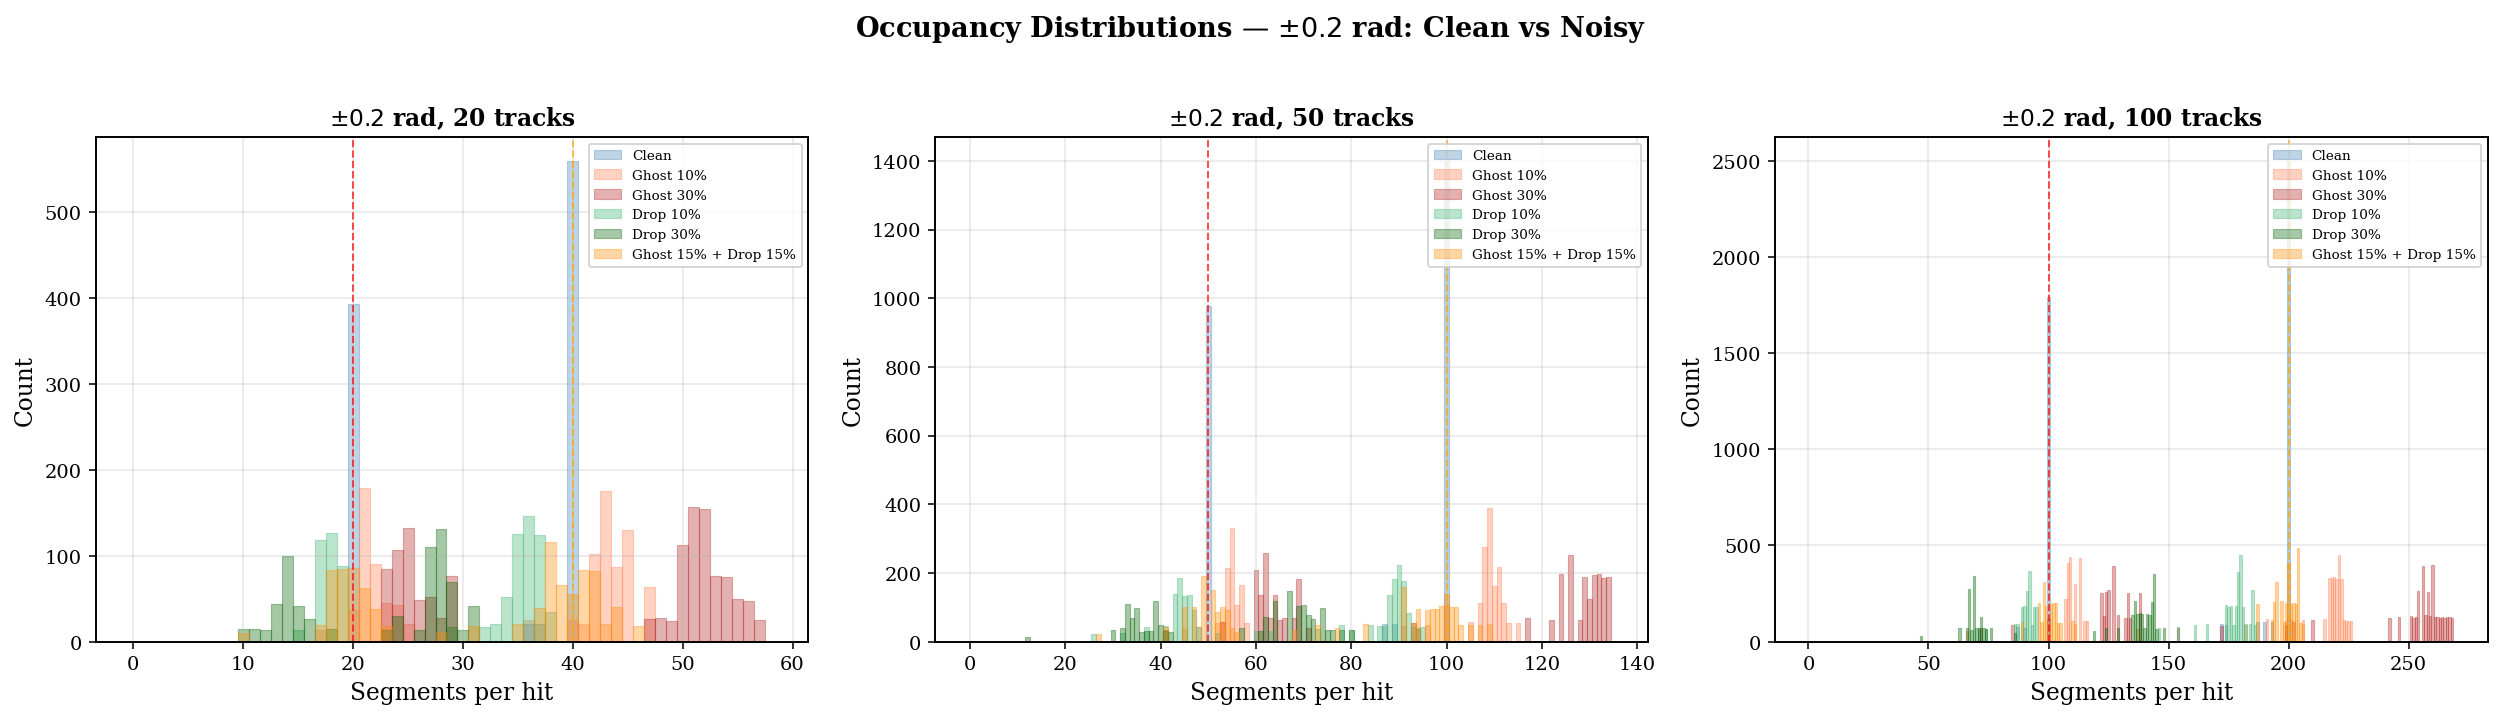

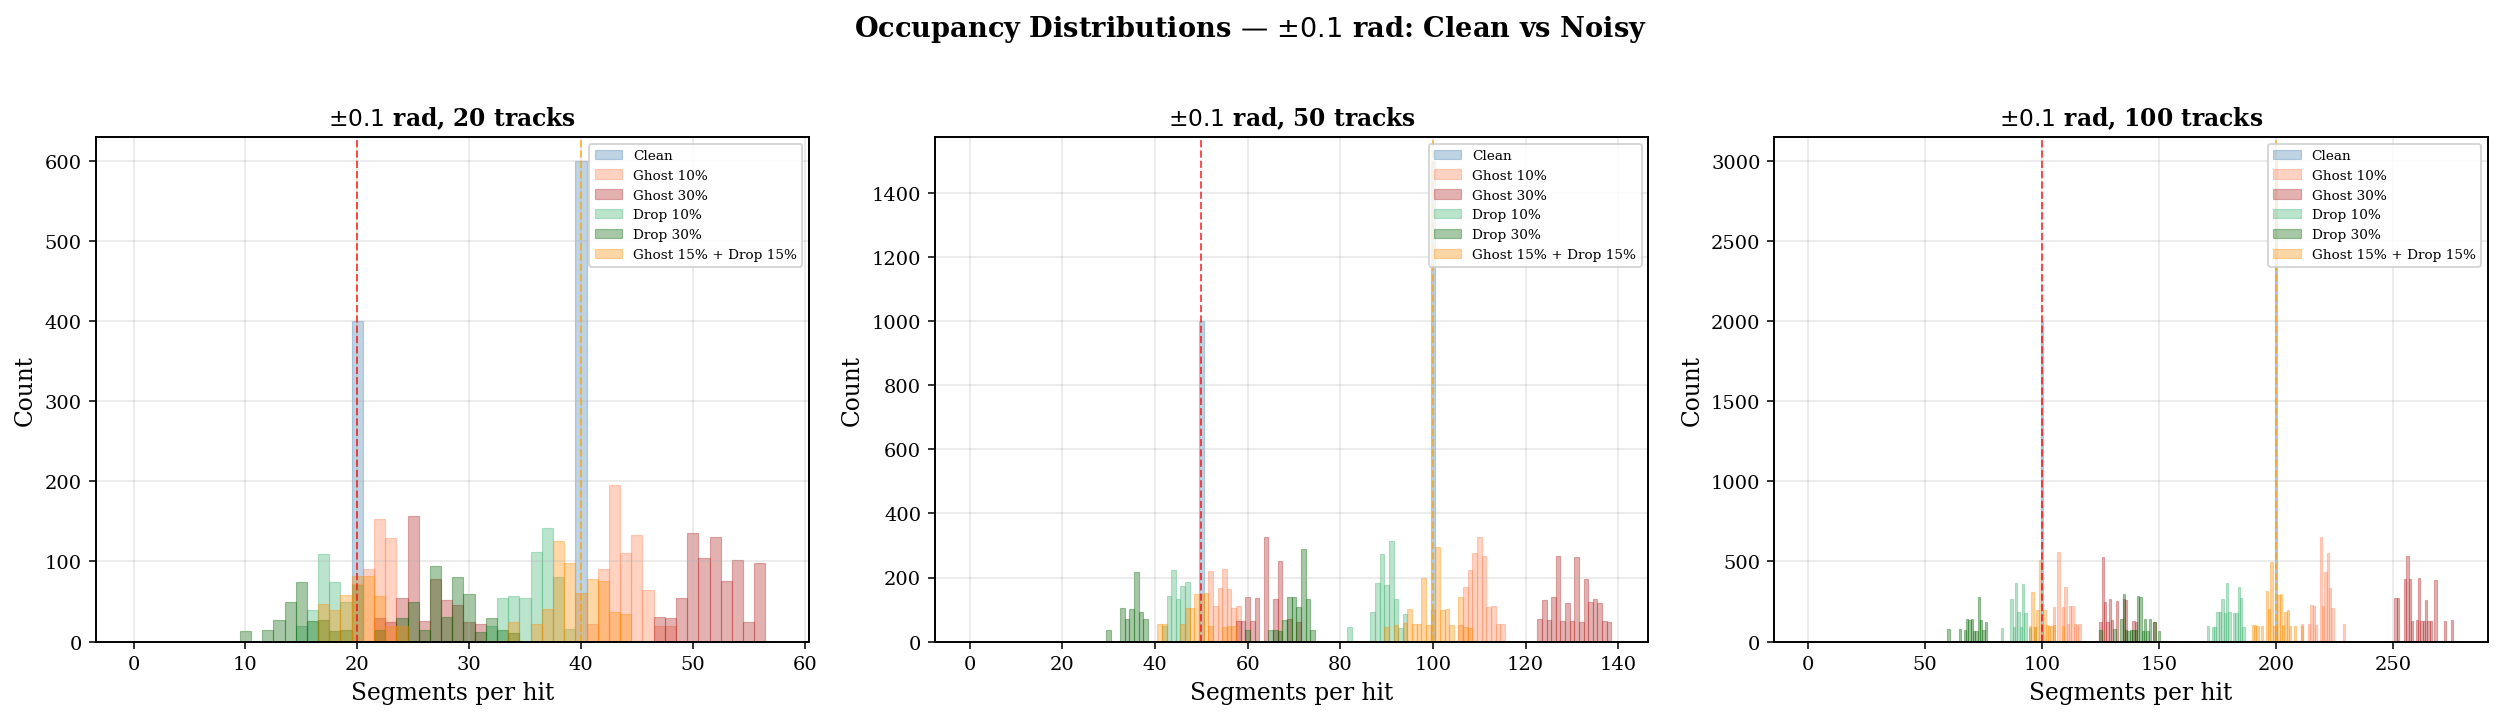

In [42]:
# ── (b) Comparing clean vs noisy: overlay histograms ─────────────
# Show how ghost and drop rates modify the occupancy distribution
# Pick representative noisy configs
noise_configs = [
    (0.0,  0.0,  "Clean",             "steelblue"),
    (0.10, 0.0,  "Ghost 10%",         "coral"),
    (0.30, 0.0,  "Ghost 30%",         "firebrick"),
    (0.0,  0.10, "Drop 10%",          "mediumseagreen"),
    (0.0,  0.30, "Drop 30%",          "darkgreen"),
    (0.15, 0.15, "Ghost 15% + Drop 15%", "darkorange"),
]

for angle in angles:
    fig, axes_row = plt.subplots(1, len(track_counts),
                                 figsize=(6 * len(track_counts), 5),
                                 squeeze=False)
    for col, n_trk in enumerate(track_counts):
        ax = axes_row[0][col]
        for gr, dr, label, color in noise_configs:
            occ = load_occ_for_params(angle, n_trk, gr, dr)
            if occ is None:
                continue
            hi = int(np.max(occ)) + 2
            bins = np.arange(0, hi + 1) - 0.5
            ax.hist(occ, bins=bins, alpha=0.35, color=color,
                    edgecolor=color, lw=0.6, label=label)

        # Mark expected peaks
        ax.axvline(n_trk, color="red", ls="--", lw=1.0, alpha=0.7)
        ax.axvline(2 * n_trk, color="orange", ls="--", lw=1.0, alpha=0.7)
        ax.set_xlabel("Segments per hit")
        ax.set_ylabel("Count")
        ax.set_title(f"$\\pm{angle}$ rad, {n_trk} tracks", fontweight="bold")
        ax.legend(fontsize=7, loc="upper right")
        ax.grid(True, alpha=0.3)

    plt.suptitle(f"Occupancy Distributions — $\\pm{angle}$ rad: Clean vs Noisy",
                 fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    save_fig(fig, f"occ_hist_comparison_angle{angle}")
    plt.show()

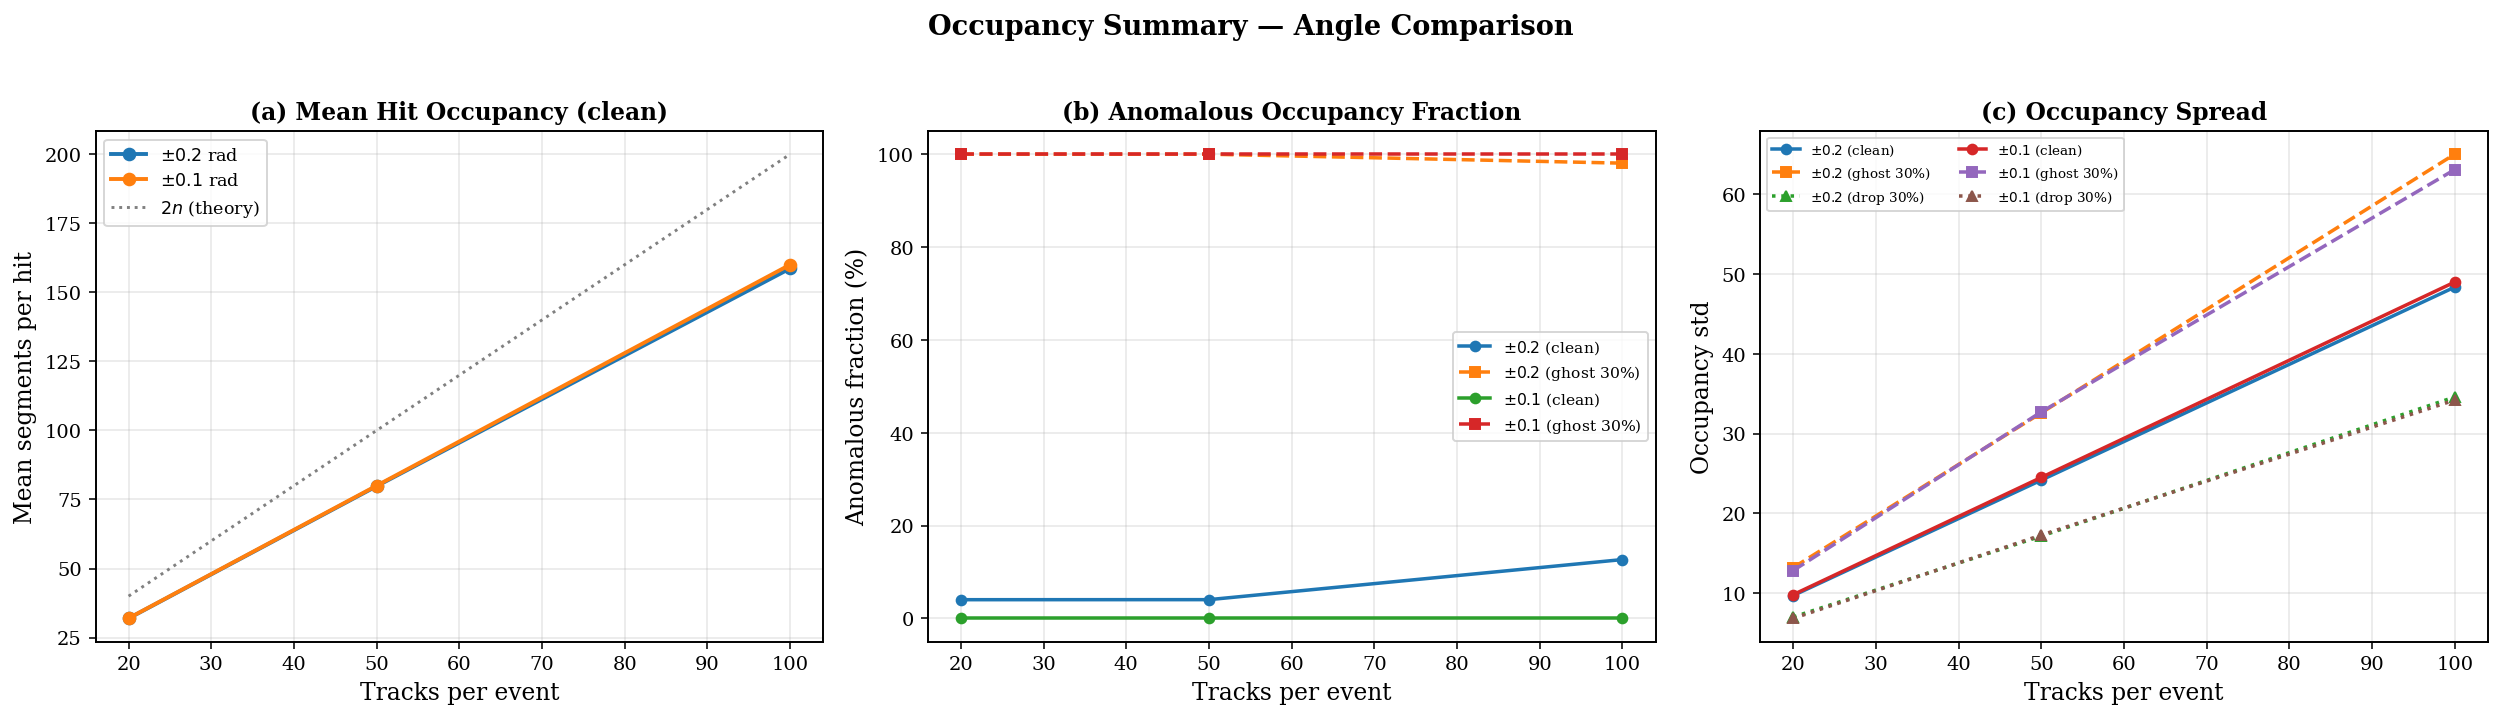

In [43]:
# ── (c) Summary statistics: mean occupancy & contested fraction ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Mean occupancy vs n_tracks for each angle (clean only)
for angle in angles:
    sub = df[(df["angle"] == angle) & (df["ghost_rate"] == 0.0) & (df["drop_rate"] == 0.0)]
    sub = sub.sort_values("n_tracks")
    axes[0].plot(sub["n_tracks"], sub["occ_mean"], "o-",
                 label=f"$\\pm{angle}$ rad", markersize=6, lw=2)
axes[0].plot(sorted(track_counts), [2 * n for n in sorted(track_counts)],
             ":", color="gray", lw=1.5, label="$2n$ (theory)")
axes[0].set_xlabel("Tracks per event")
axes[0].set_ylabel("Mean segments per hit")
axes[0].set_title("(a) Mean Hit Occupancy (clean)", fontweight="bold")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Anomalous fraction vs n_tracks, comparing clean vs ghost=30%
for angle in angles:
    for gr, ls, label_sfx in [(0.0, "o-", "clean"), (0.30, "s--", "ghost 30%")]:
        sub = df[(df["angle"] == angle) & (df["ghost_rate"] == gr) & (df["drop_rate"] == 0.0)]
        sub = sub.sort_values("n_tracks")
        axes[1].plot(sub["n_tracks"], sub["frac_anomalous_occ"] * 100,
                     ls, label=f"$\\pm{angle}$ ({label_sfx})", markersize=5, lw=1.8)
axes[1].set_xlabel("Tracks per event")
axes[1].set_ylabel("Anomalous fraction (%)")
axes[1].set_title("(b) Anomalous Occupancy Fraction", fontweight="bold")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# Occupancy std vs n_tracks, comparing clean vs noisy
for angle in angles:
    for gr, dr, ls, label_sfx in [(0.0, 0.0, "o-", "clean"),
                                   (0.30, 0.0, "s--", "ghost 30%"),
                                   (0.0, 0.30, "^:", "drop 30%")]:
        sub = df[(df["angle"] == angle) & (df["ghost_rate"] == gr) & (df["drop_rate"] == dr)]
        sub = sub.sort_values("n_tracks")
        axes[2].plot(sub["n_tracks"], sub["occ_std"],
                     ls, label=f"$\\pm{angle}$ ({label_sfx})", markersize=5, lw=1.8)
axes[2].set_xlabel("Tracks per event")
axes[2].set_ylabel("Occupancy std")
axes[2].set_title("(c) Occupancy Spread", fontweight="bold")
axes[2].legend(fontsize=7, ncol=2)
axes[2].grid(True, alpha=0.3)

plt.suptitle("Occupancy Summary — Angle Comparison",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
save_fig(fig, "occ_summary_comparison")
plt.show()

---
## 1. Anomalous Occupancy Fraction — Heatmaps

The fraction of hit-occupancy values that fall outside the expected peaks ($n$ and $2n$) is the primary diagnostic for "segment grass". We plot this as heatmaps across the ghost-rate × drop-rate grid, comparing ±0.2 rad (where geometric clipping causes grass) and ±0.1 rad (control).

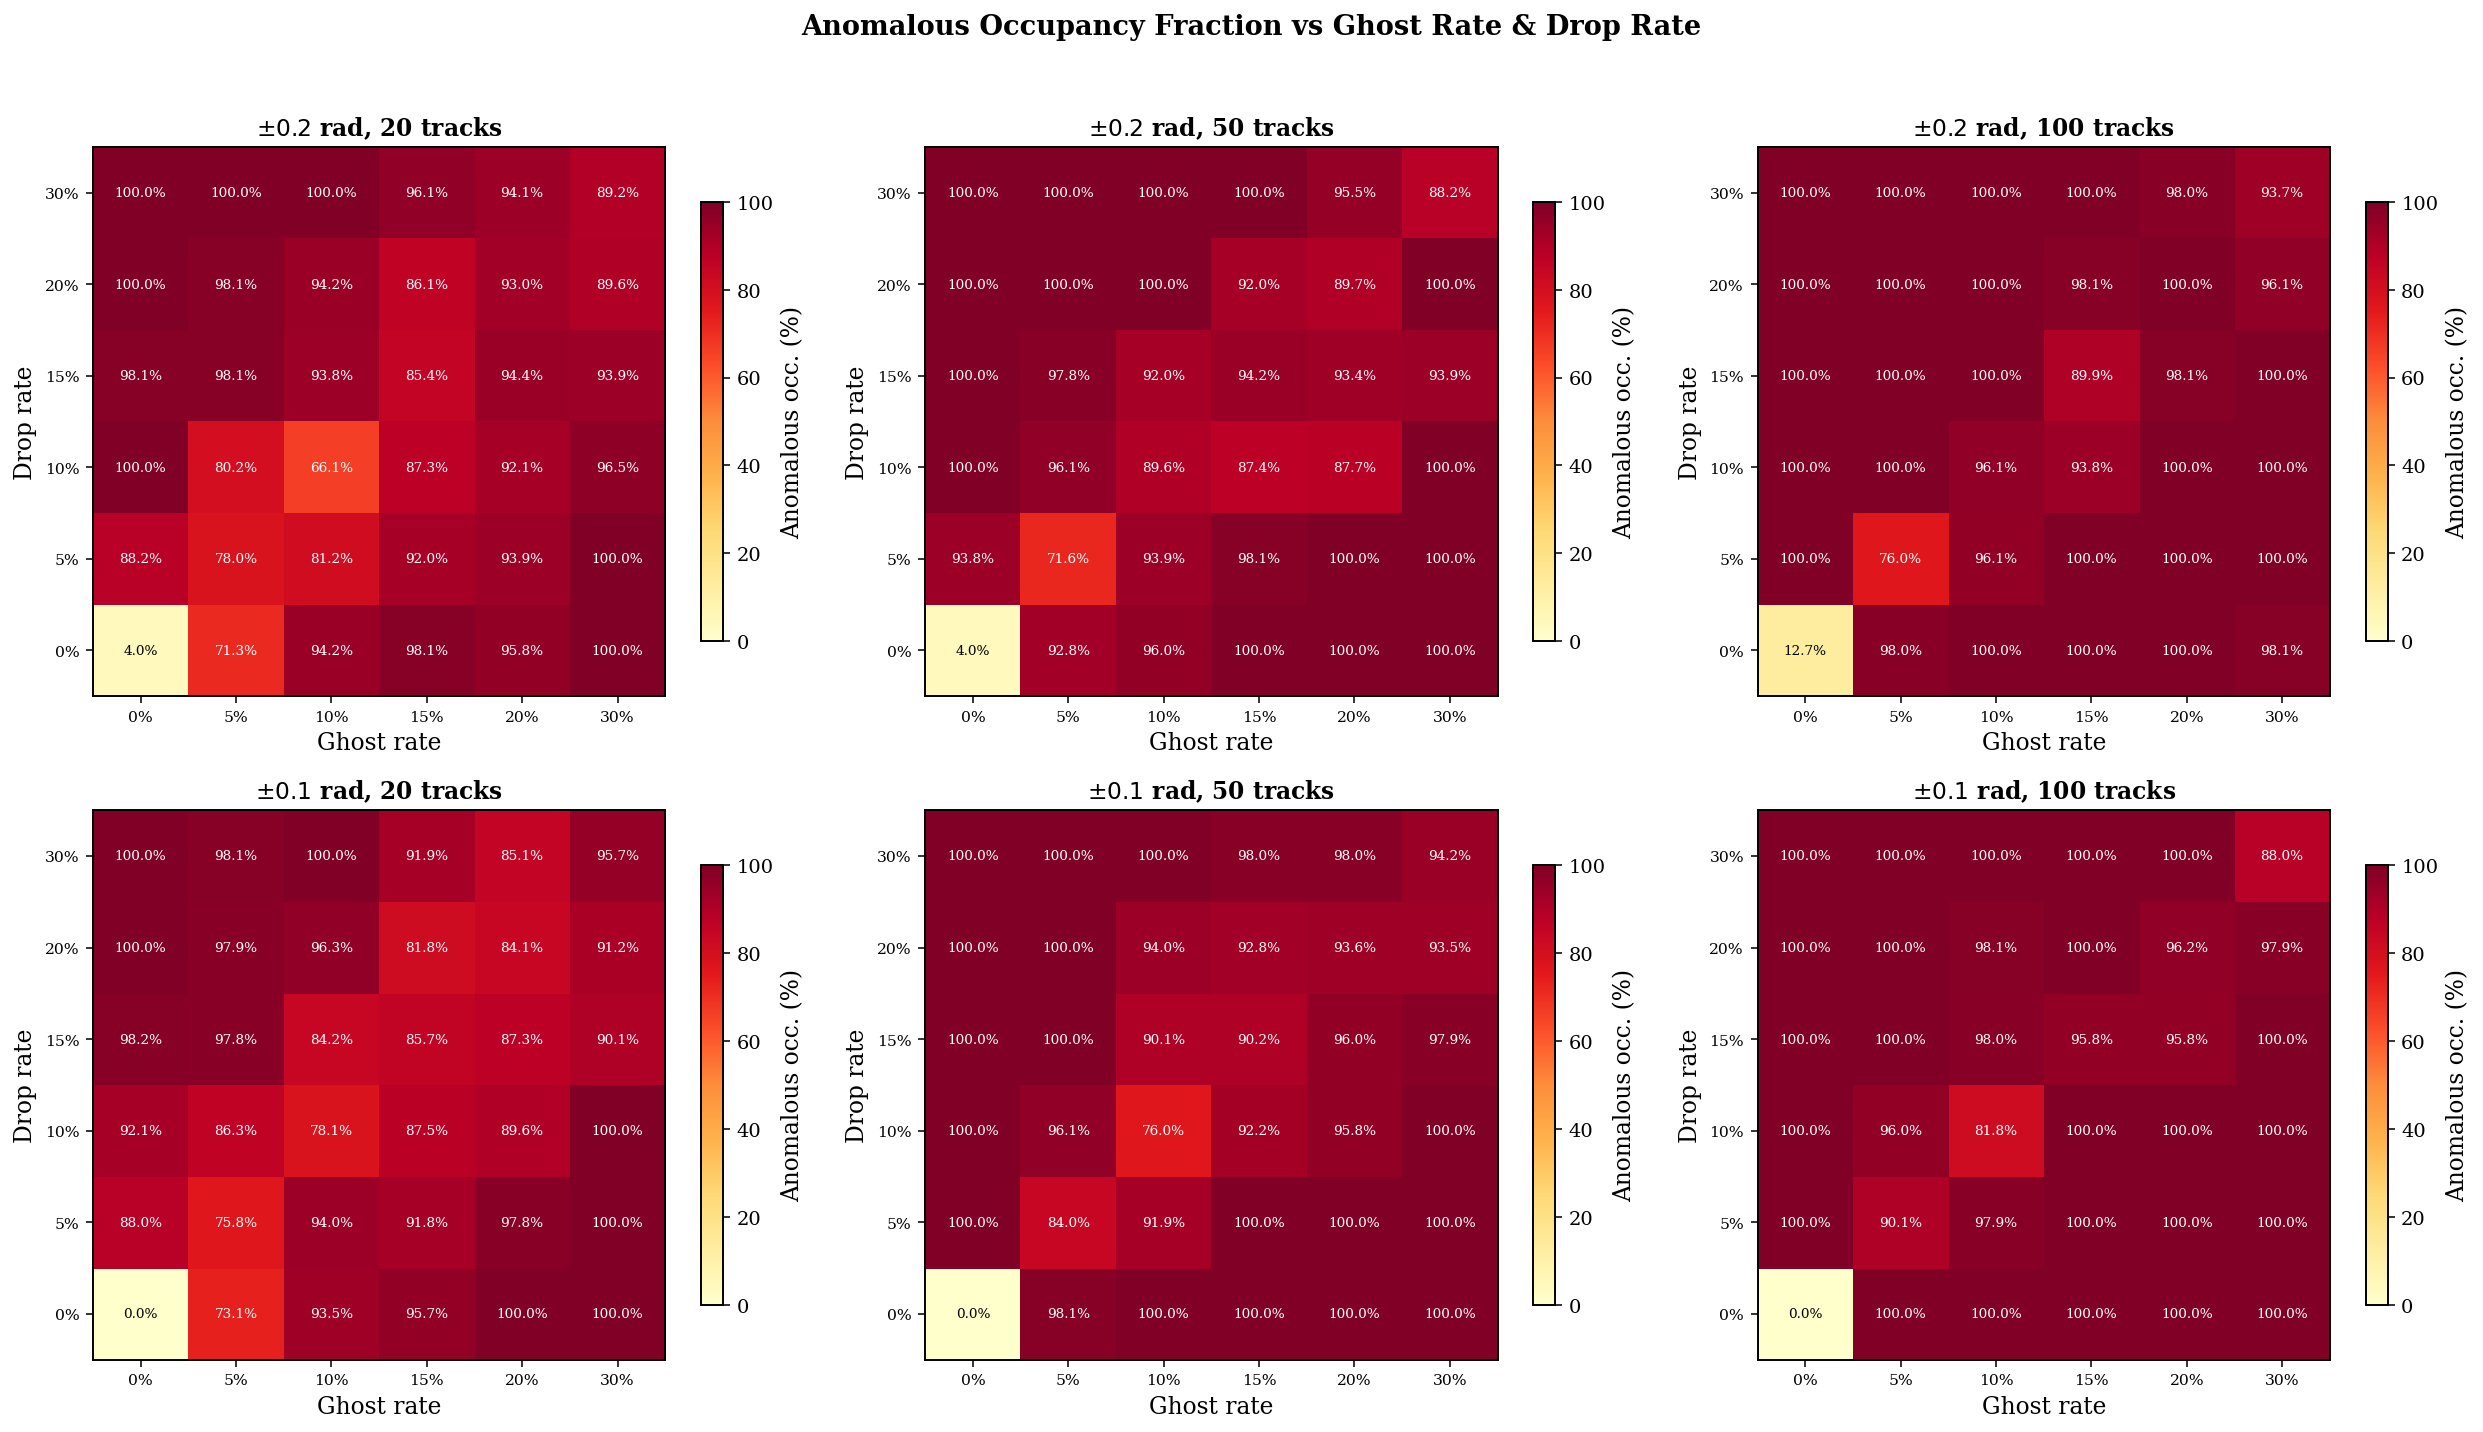

In [44]:
# ── Heatmaps: anomalous occupancy fraction ──────────────────────
angles = sorted(df["angle"].unique(), reverse=True)
track_counts = sorted(df["n_tracks"].unique())
ghost_rates = sorted(df["ghost_rate"].unique())
drop_rates = sorted(df["drop_rate"].unique())

fig, axes = plt.subplots(len(angles), len(track_counts),
                         figsize=(6 * len(track_counts),
                                  5 * len(angles)),
                         squeeze=False)

for row, angle in enumerate(angles):
    for col, n_trk in enumerate(track_counts):
        ax = axes[row][col]
        sub = df[(df["angle"] == angle) & (df["n_tracks"] == n_trk)]

        # Pivot to heatmap
        piv = sub.pivot_table(
            index="drop_rate", columns="ghost_rate",
            values="frac_anomalous_occ", aggfunc="first")
        piv = piv.reindex(index=drop_rates, columns=ghost_rates)

        im = ax.imshow(piv.values * 100, aspect="auto",
                       cmap="YlOrRd", origin="lower",
                       vmin=0, vmax=max(df["frac_anomalous_occ"].max() * 100, 1))

        ax.set_xticks(range(len(ghost_rates)))
        ax.set_xticklabels([f"{g:.0%}" for g in ghost_rates], fontsize=8)
        ax.set_yticks(range(len(drop_rates)))
        ax.set_yticklabels([f"{d:.0%}" for d in drop_rates], fontsize=8)
        ax.set_xlabel("Ghost rate")
        ax.set_ylabel("Drop rate")
        ax.set_title(f"$\\pm{angle}$ rad, {n_trk} tracks", fontweight="bold")

        # Annotate cells
        for i in range(len(drop_rates)):
            for j in range(len(ghost_rates)):
                val = piv.values[i, j] * 100
                if not np.isnan(val):
                    color = "white" if val > 30 else "black"
                    ax.text(j, i, f"{val:.1f}%", ha="center", va="center",
                            fontsize=7, color=color)

        plt.colorbar(im, ax=ax, label="Anomalous occ. (%)", shrink=0.8)

plt.suptitle("Anomalous Occupancy Fraction vs Ghost Rate & Drop Rate",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
save_fig(fig, "heatmap_anomalous_occ")
plt.show()

## Section 2 — Occupancy Standard Deviation vs Ghost / Drop Rate

The standard deviation of the occupancy distribution measures how "spiky" the distribution is. Higher values indicate more anomalous peaks (segment grass). We plot this as a function of ghost rate and drop rate, separated by angle and track count.

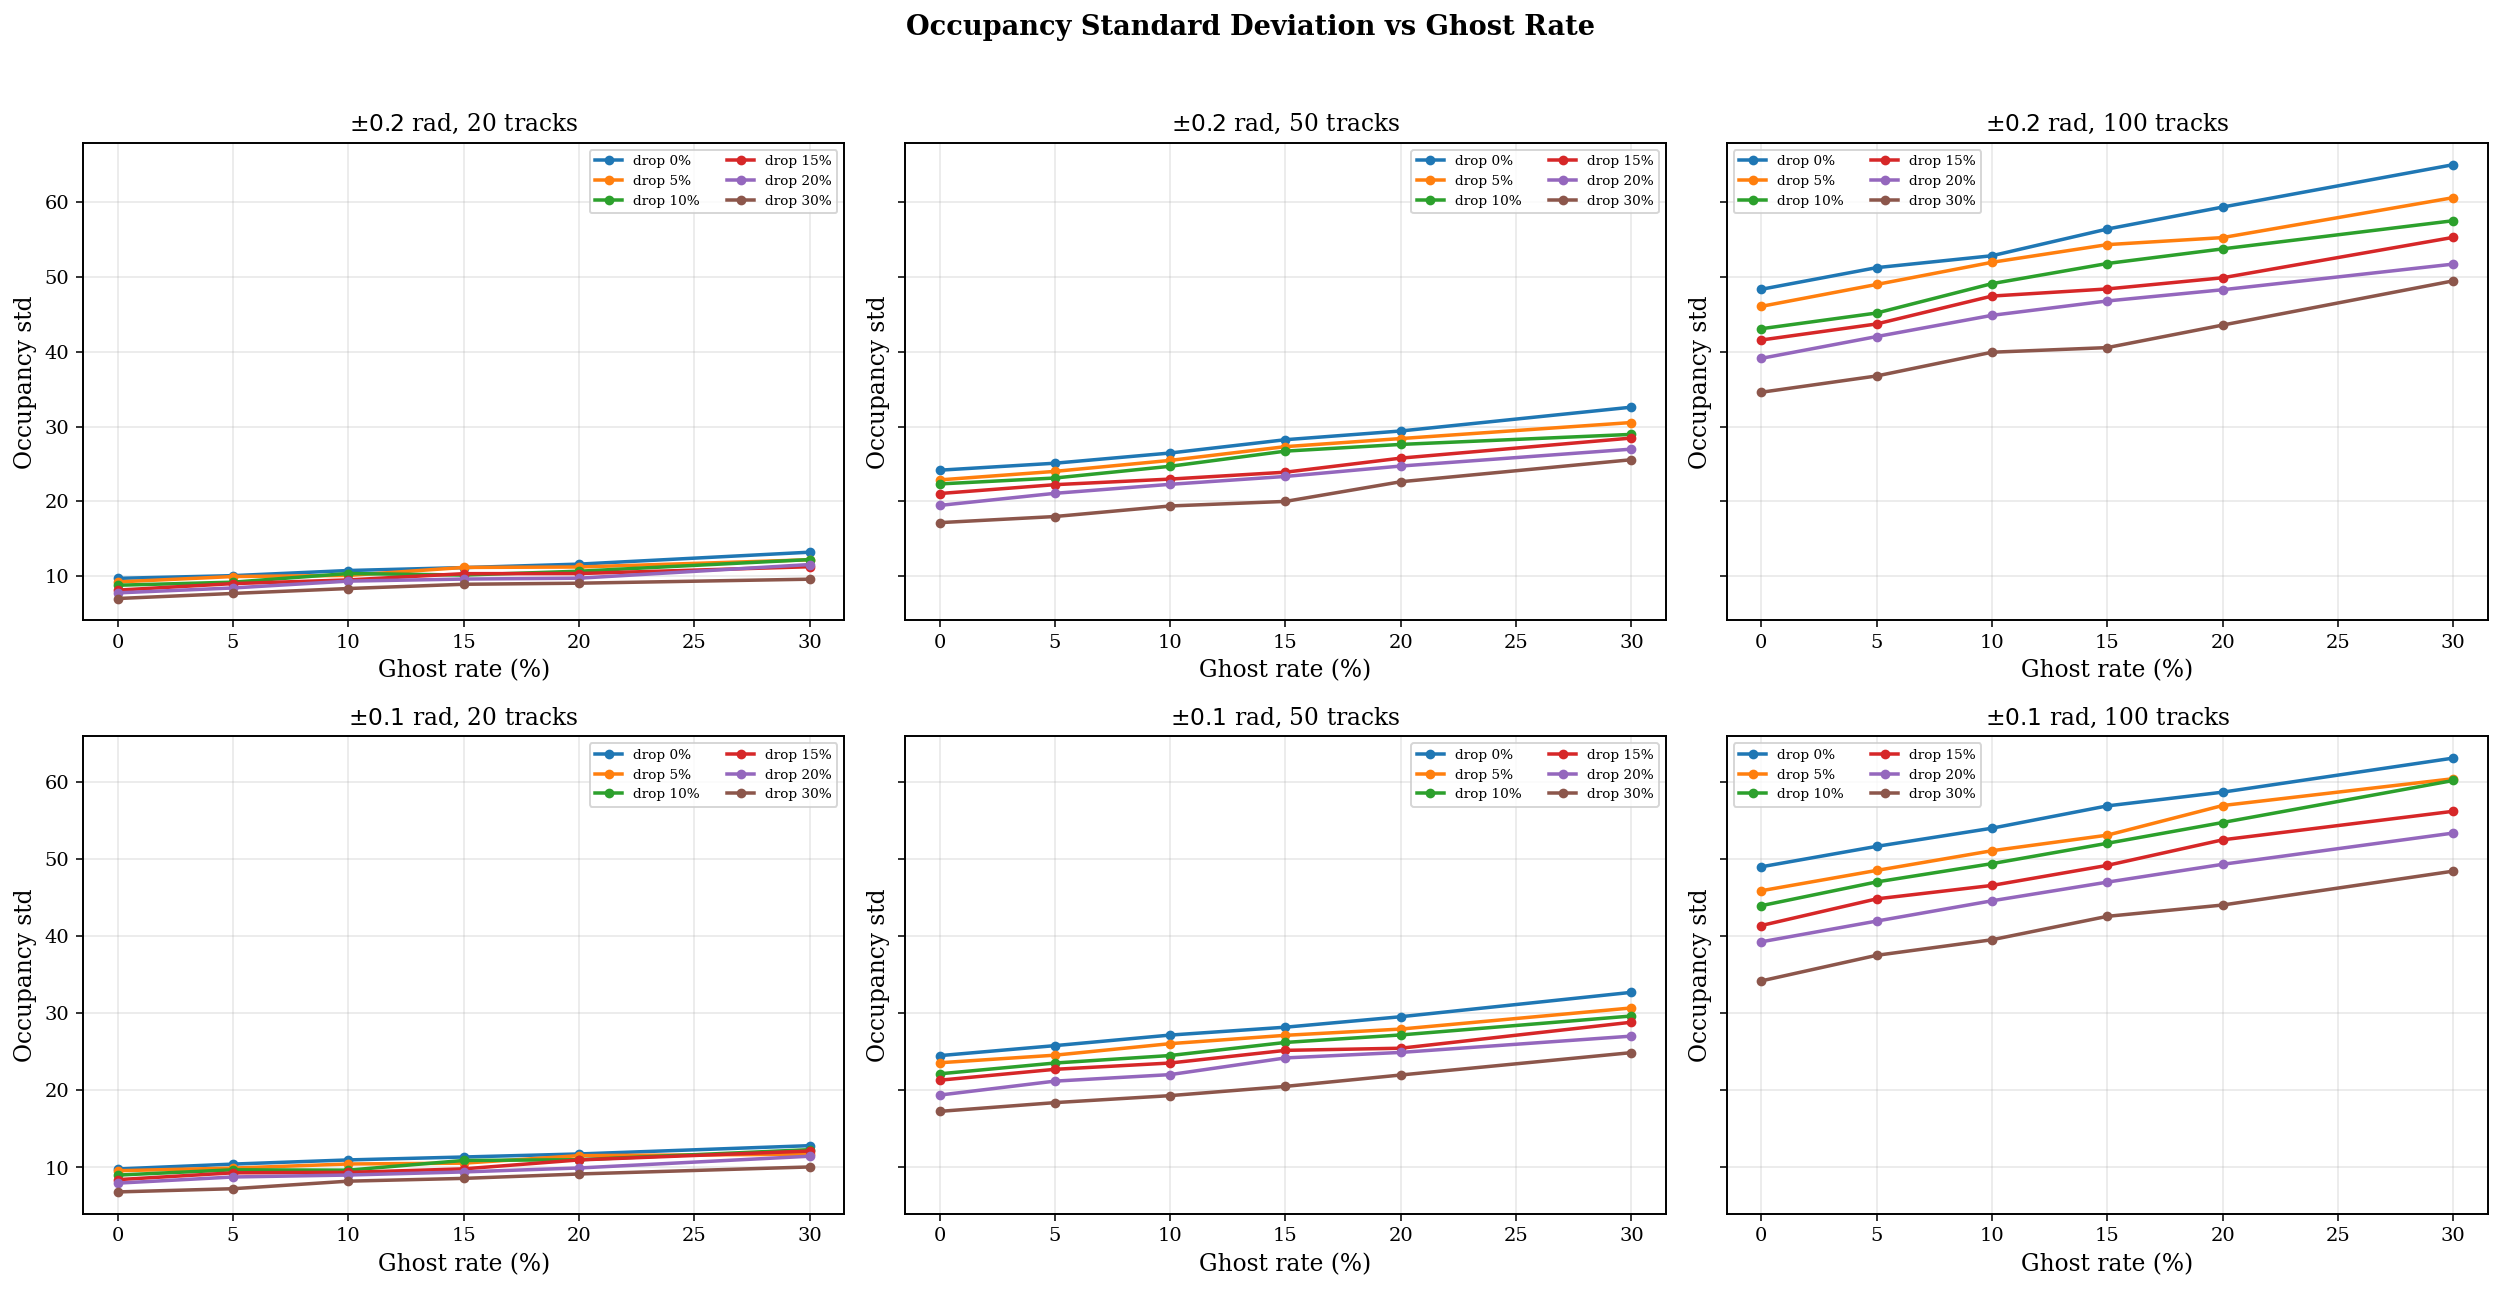

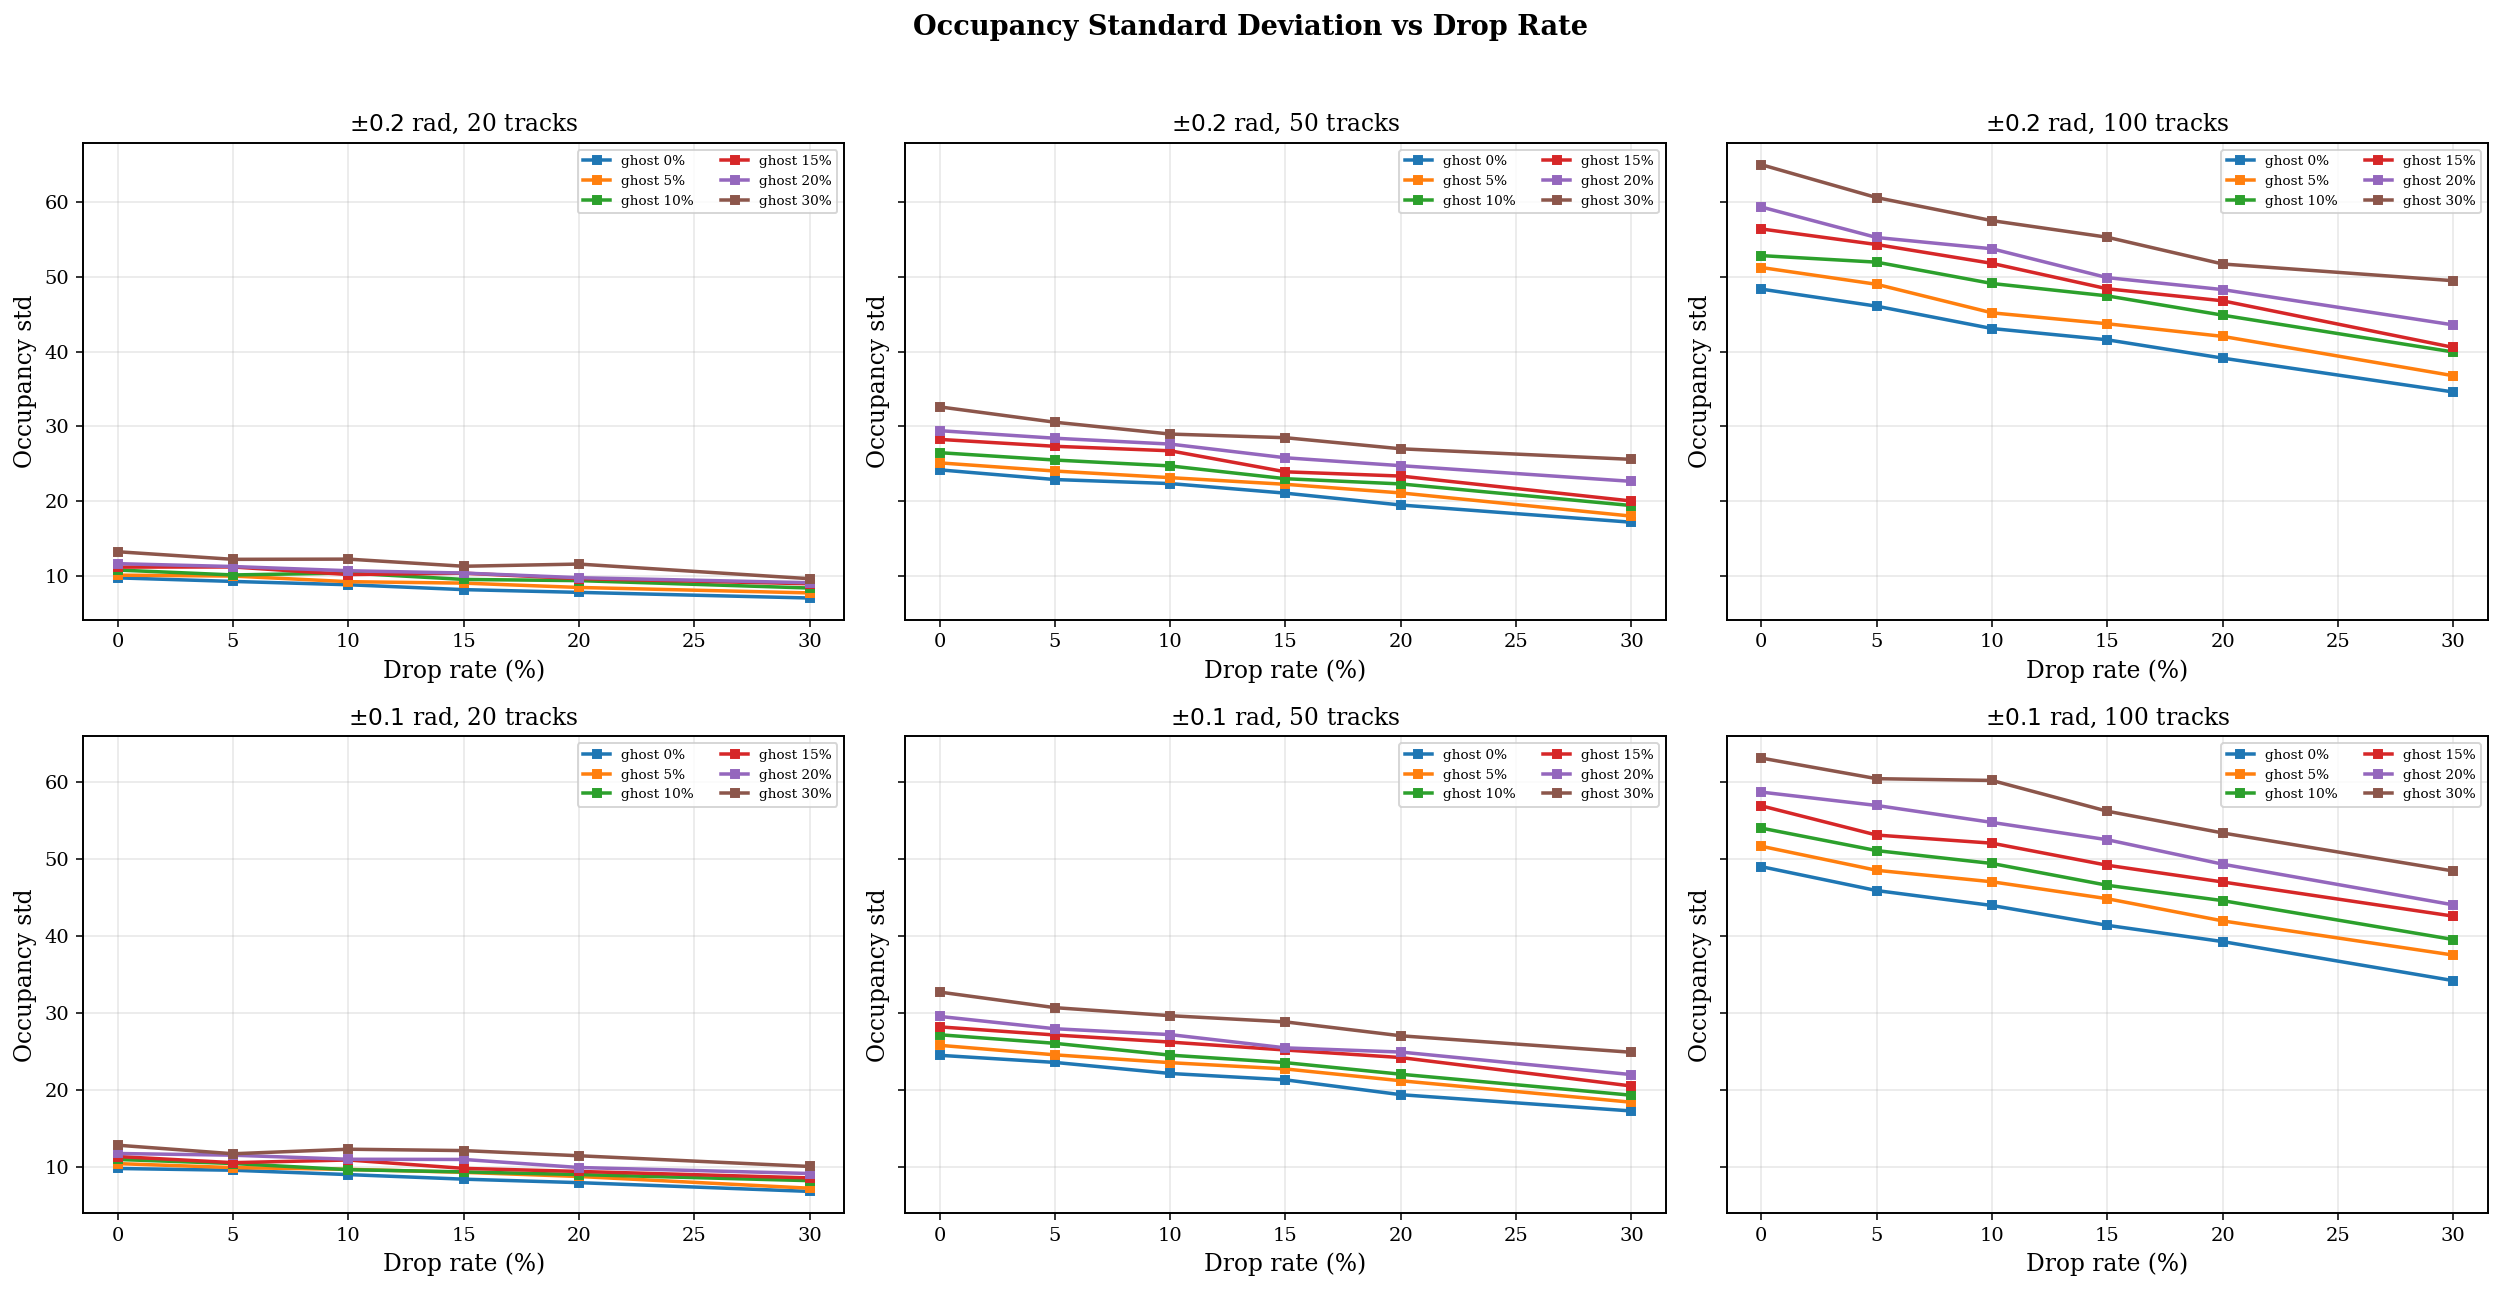

In [45]:
# ── Occupancy std vs ghost rate (lines, one curve per drop rate) ──
fig, axes = plt.subplots(len(angles), len(track_counts),
                         figsize=(6 * len(track_counts),
                                  4.5 * len(angles)),
                         squeeze=False, sharey="row")

for row, angle in enumerate(angles):
    for col, n_trk in enumerate(track_counts):
        ax = axes[row][col]
        sub = df[(df["angle"] == angle) & (df["n_tracks"] == n_trk)]

        for dr in drop_rates:
            curve = sub[sub["drop_rate"] == dr].sort_values("ghost_rate")
            ax.plot(curve["ghost_rate"] * 100, curve["occ_std"],
                    "o-", label=f"drop {dr:.0%}", markersize=4)

        ax.set_xlabel("Ghost rate (%)")
        ax.set_ylabel("Occupancy std")
        ax.set_title(f"$\\pm{angle}$ rad, {n_trk} tracks")
        ax.legend(fontsize=7, ncol=2)
        ax.grid(True, alpha=0.3)

plt.suptitle("Occupancy Standard Deviation vs Ghost Rate",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
save_fig(fig, "occ_std_vs_ghost")
plt.show()

# ── Same, but vs drop rate (one curve per ghost rate) ──
fig, axes = plt.subplots(len(angles), len(track_counts),
                         figsize=(6 * len(track_counts),
                                  4.5 * len(angles)),
                         squeeze=False, sharey="row")

for row, angle in enumerate(angles):
    for col, n_trk in enumerate(track_counts):
        ax = axes[row][col]
        sub = df[(df["angle"] == angle) & (df["n_tracks"] == n_trk)]

        for gr in ghost_rates:
            curve = sub[sub["ghost_rate"] == gr].sort_values("drop_rate")
            ax.plot(curve["drop_rate"] * 100, curve["occ_std"],
                    "s-", label=f"ghost {gr:.0%}", markersize=4)

        ax.set_xlabel("Drop rate (%)")
        ax.set_ylabel("Occupancy std")
        ax.set_title(f"$\\pm{angle}$ rad, {n_trk} tracks")
        ax.legend(fontsize=7, ncol=2)
        ax.grid(True, alpha=0.3)

plt.suptitle("Occupancy Standard Deviation vs Drop Rate",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
save_fig(fig, "occ_std_vs_drop")
plt.show()

## Section 3 — Hits Per Module Variability

Geometric clipping removes hits from the outermost modules for tracks at large angles. Ghost and dropped hits modify the per-module hit counts. We examine the coefficient of variation (std/mean) of hits across modules.

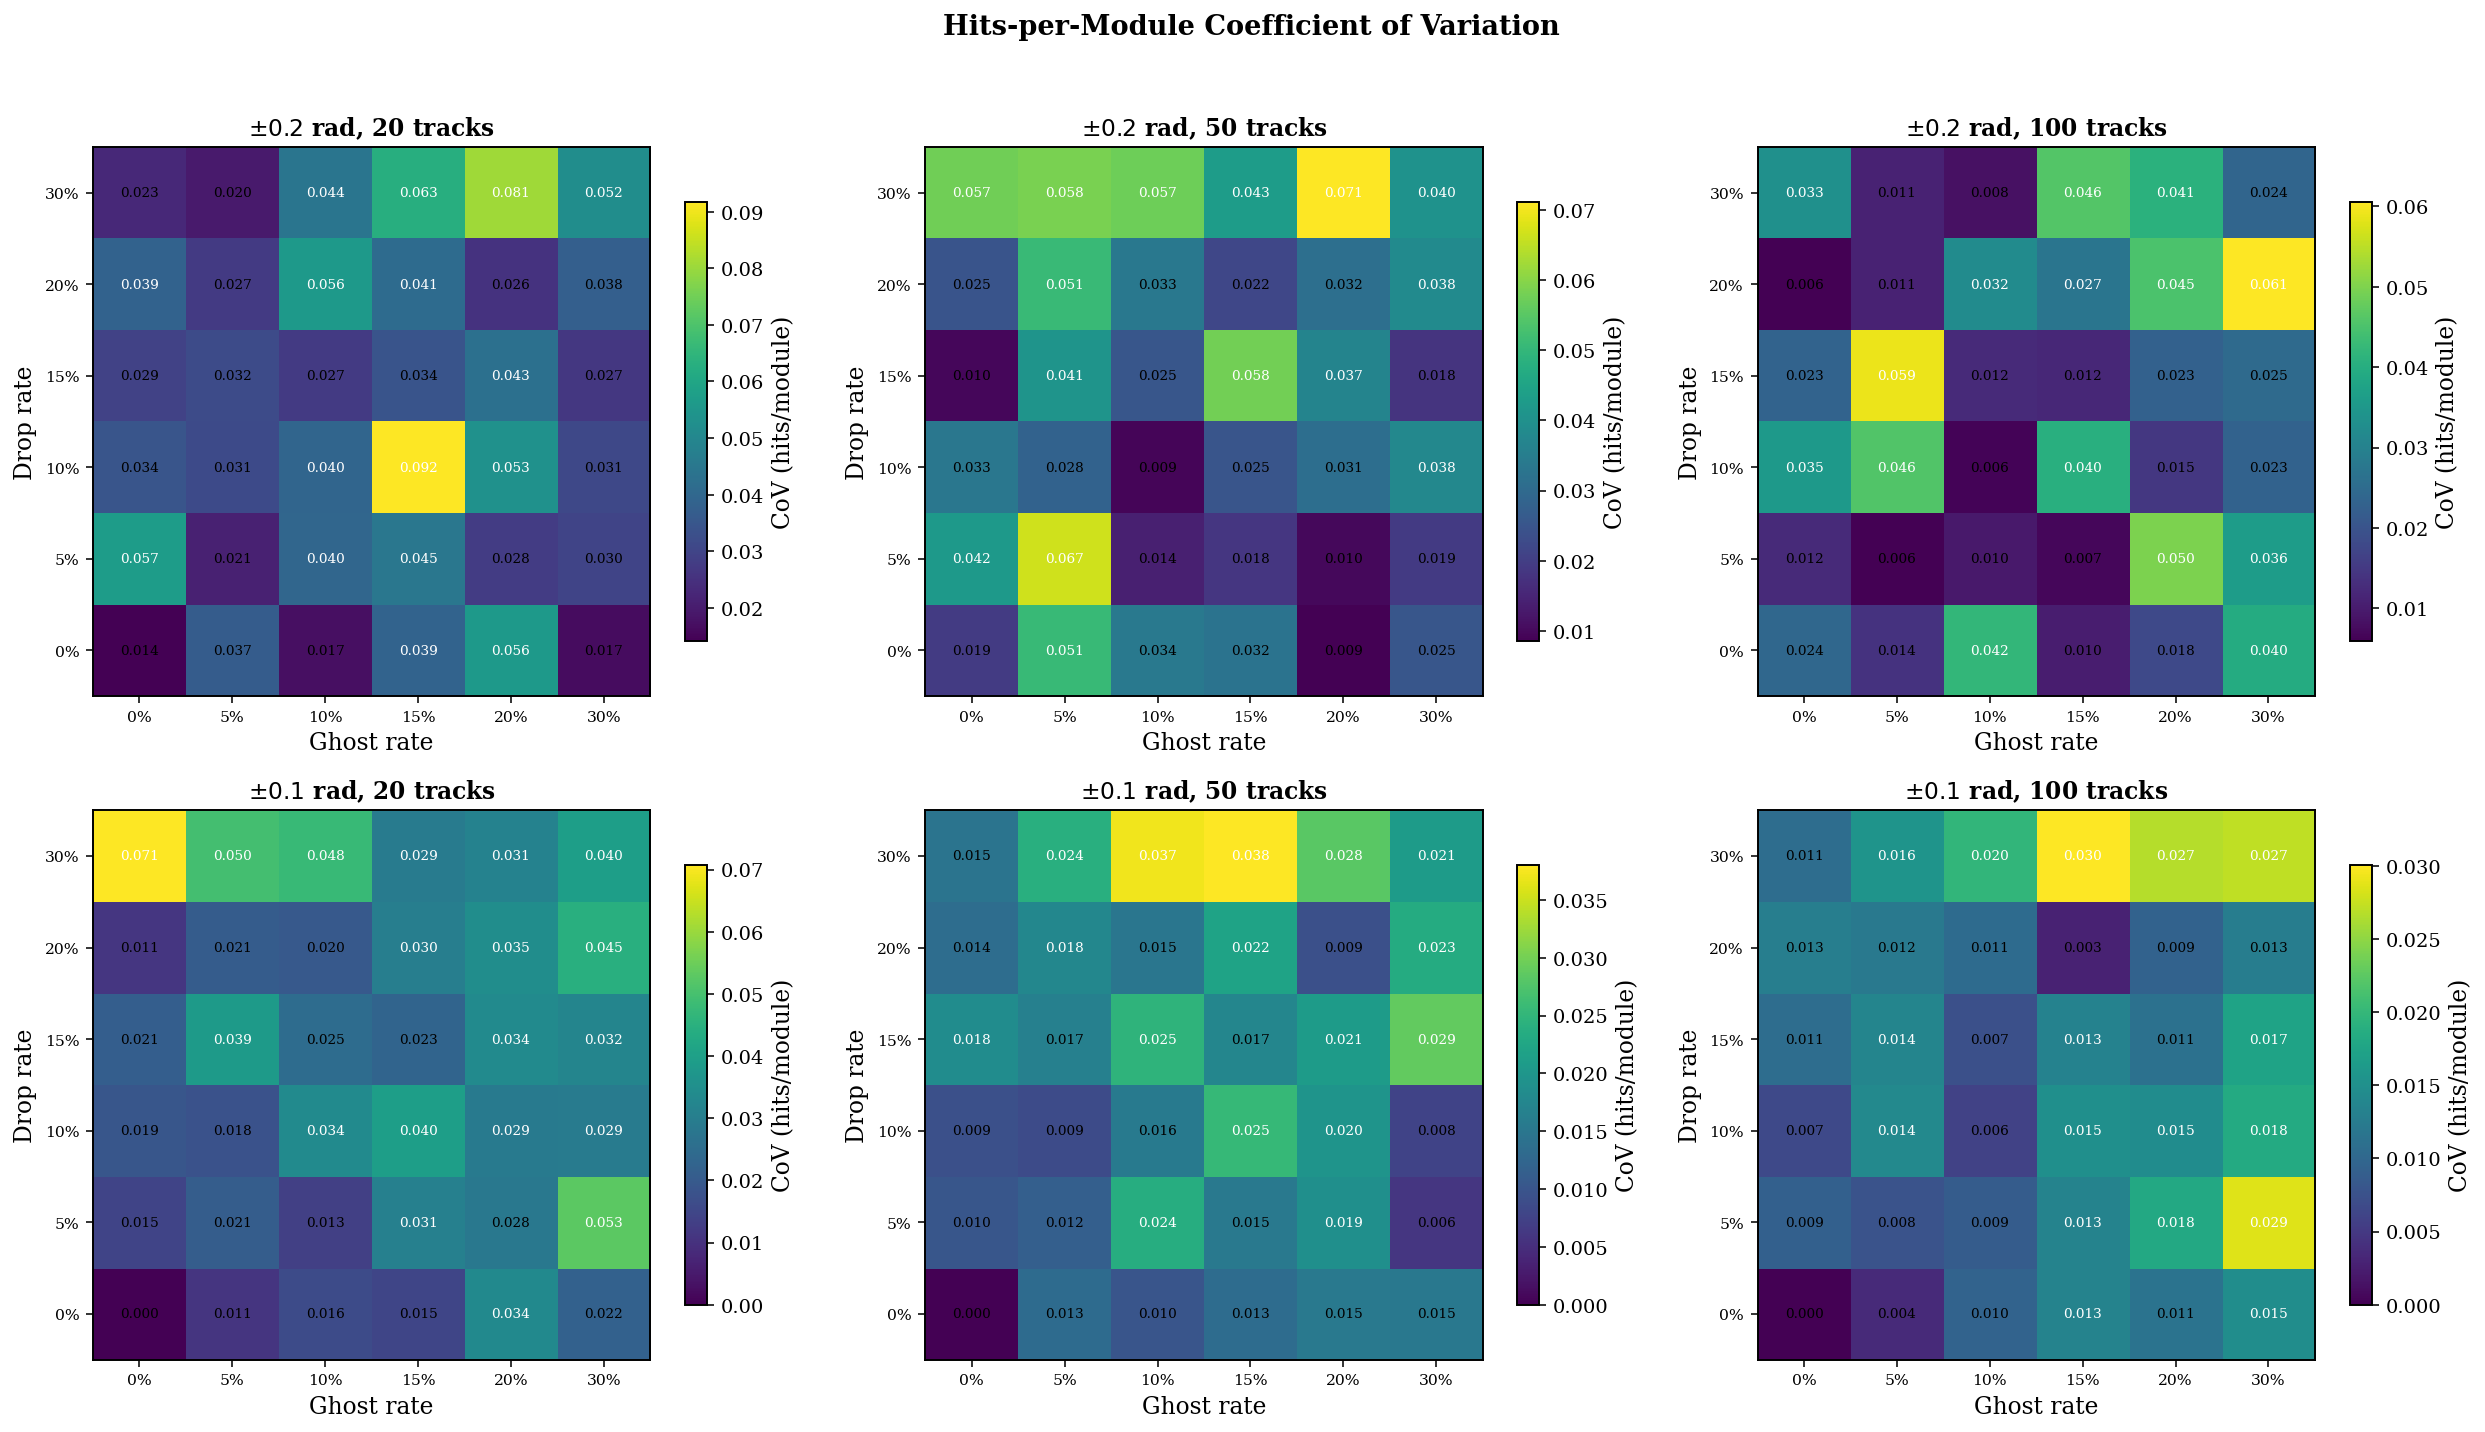

In [46]:
# ── Hits-per-module coefficient of variation heatmaps ──────────
# Compute CoV from per-module mean columns
mod_cols = [f"hits_mod{m}_mean" for m in range(5)]
available_mod_cols = [c for c in mod_cols if c in df.columns]

if len(available_mod_cols) >= 2:
    mod_arr = df[available_mod_cols].values
    df["hits_per_module_cv"] = np.std(mod_arr, axis=1) / np.clip(np.mean(mod_arr, axis=1), 1e-9, None)

    fig, axes = plt.subplots(len(angles), len(track_counts),
                             figsize=(6 * len(track_counts),
                                      5 * len(angles)),
                             squeeze=False)

    for row, angle in enumerate(angles):
        for col, n_trk in enumerate(track_counts):
            ax = axes[row][col]
            sub = df[(df["angle"] == angle) & (df["n_tracks"] == n_trk)]

            piv = sub.pivot_table(
                index="drop_rate", columns="ghost_rate",
                values="hits_per_module_cv", aggfunc="first")
            piv = piv.reindex(index=drop_rates, columns=ghost_rates)

            im = ax.imshow(piv.values, aspect="auto",
                           cmap="viridis", origin="lower")

            ax.set_xticks(range(len(ghost_rates)))
            ax.set_xticklabels([f"{g:.0%}" for g in ghost_rates], fontsize=8)
            ax.set_yticks(range(len(drop_rates)))
            ax.set_yticklabels([f"{d:.0%}" for d in drop_rates], fontsize=8)
            ax.set_xlabel("Ghost rate")
            ax.set_ylabel("Drop rate")
            ax.set_title(f"$\\pm{angle}$ rad, {n_trk} tracks", fontweight="bold")

            for i in range(len(drop_rates)):
                for j in range(len(ghost_rates)):
                    val = piv.values[i, j]
                    if not np.isnan(val):
                        color = "white" if val > piv.values[~np.isnan(piv.values)].mean() else "black"
                        ax.text(j, i, f"{val:.3f}", ha="center", va="center",
                                fontsize=7, color=color)

            plt.colorbar(im, ax=ax, label="CoV (hits/module)", shrink=0.8)

    plt.suptitle("Hits-per-Module Coefficient of Variation",
                 fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    save_fig(fig, "heatmap_hits_module_cv")
    plt.show()
else:
    print("Per-module hit columns not found in data — skipping.")

## Section 4 — Reconstruction Metrics

How do ghost and drop rates affect reconstruction performance? We examine:
- **Reconstruction efficiency** (fraction of true tracks found)
- **Ghost track rate** (fraction of reconstructed tracks with no true match)
- **Clone fraction** (duplicate matches among matched tracks)

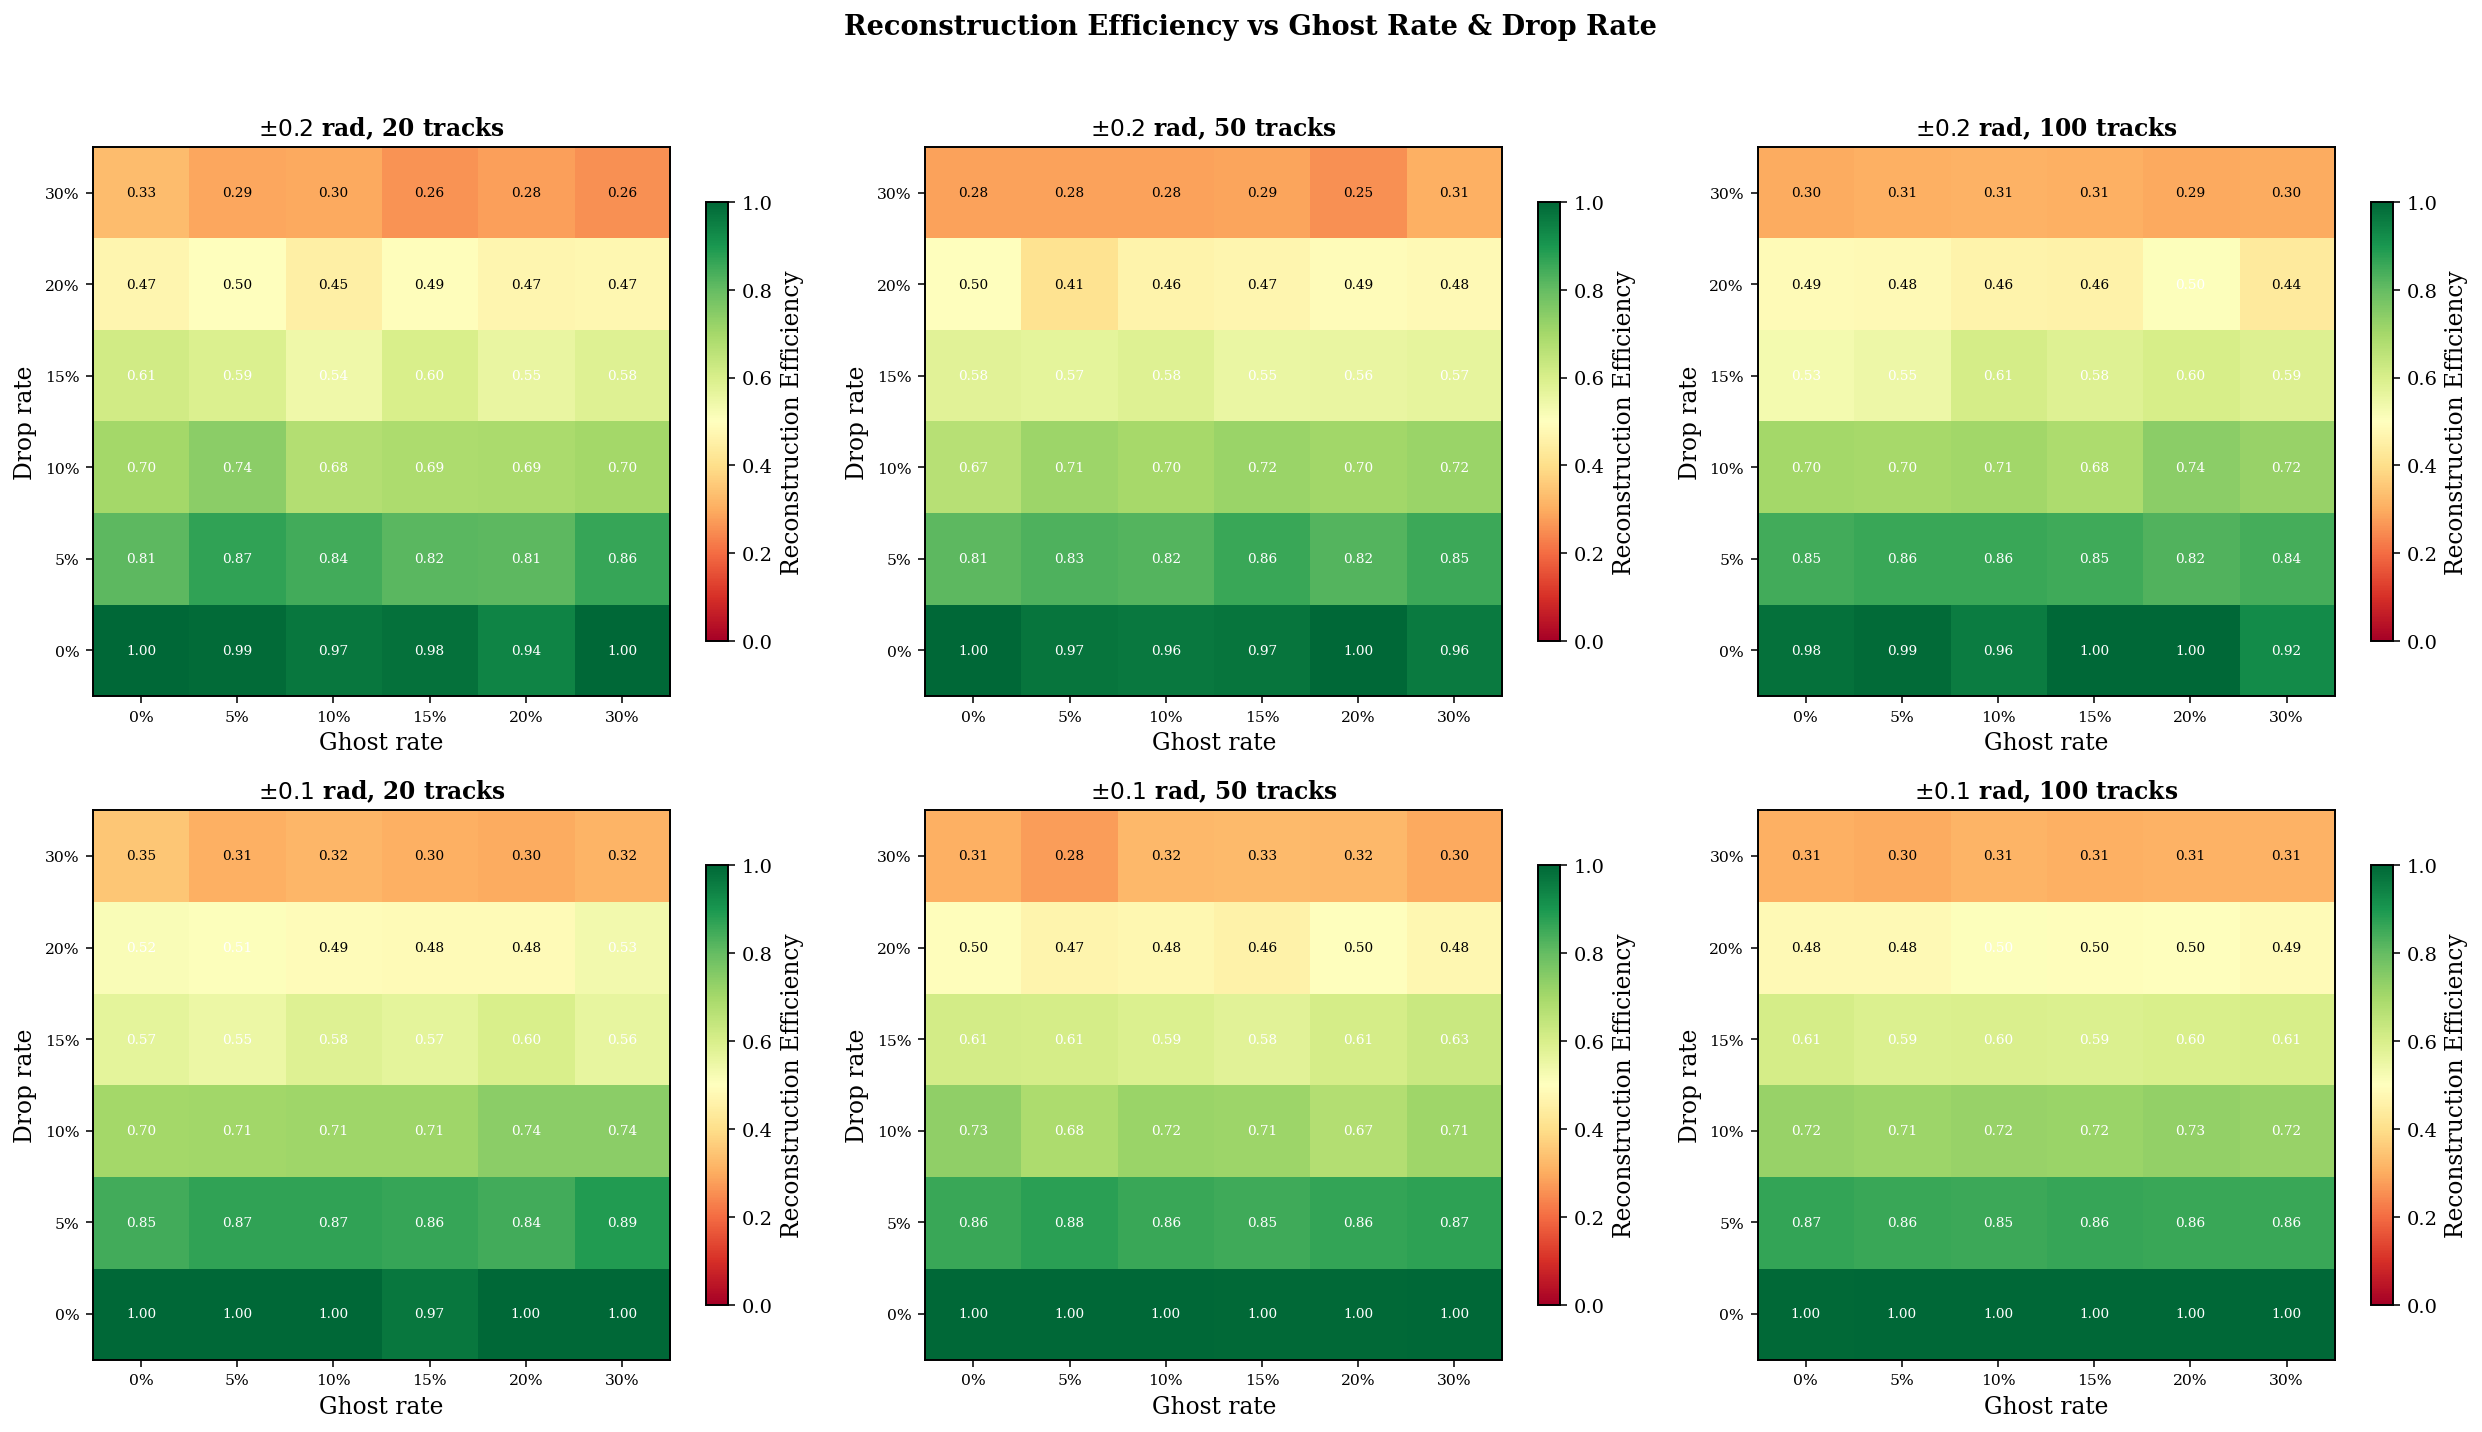

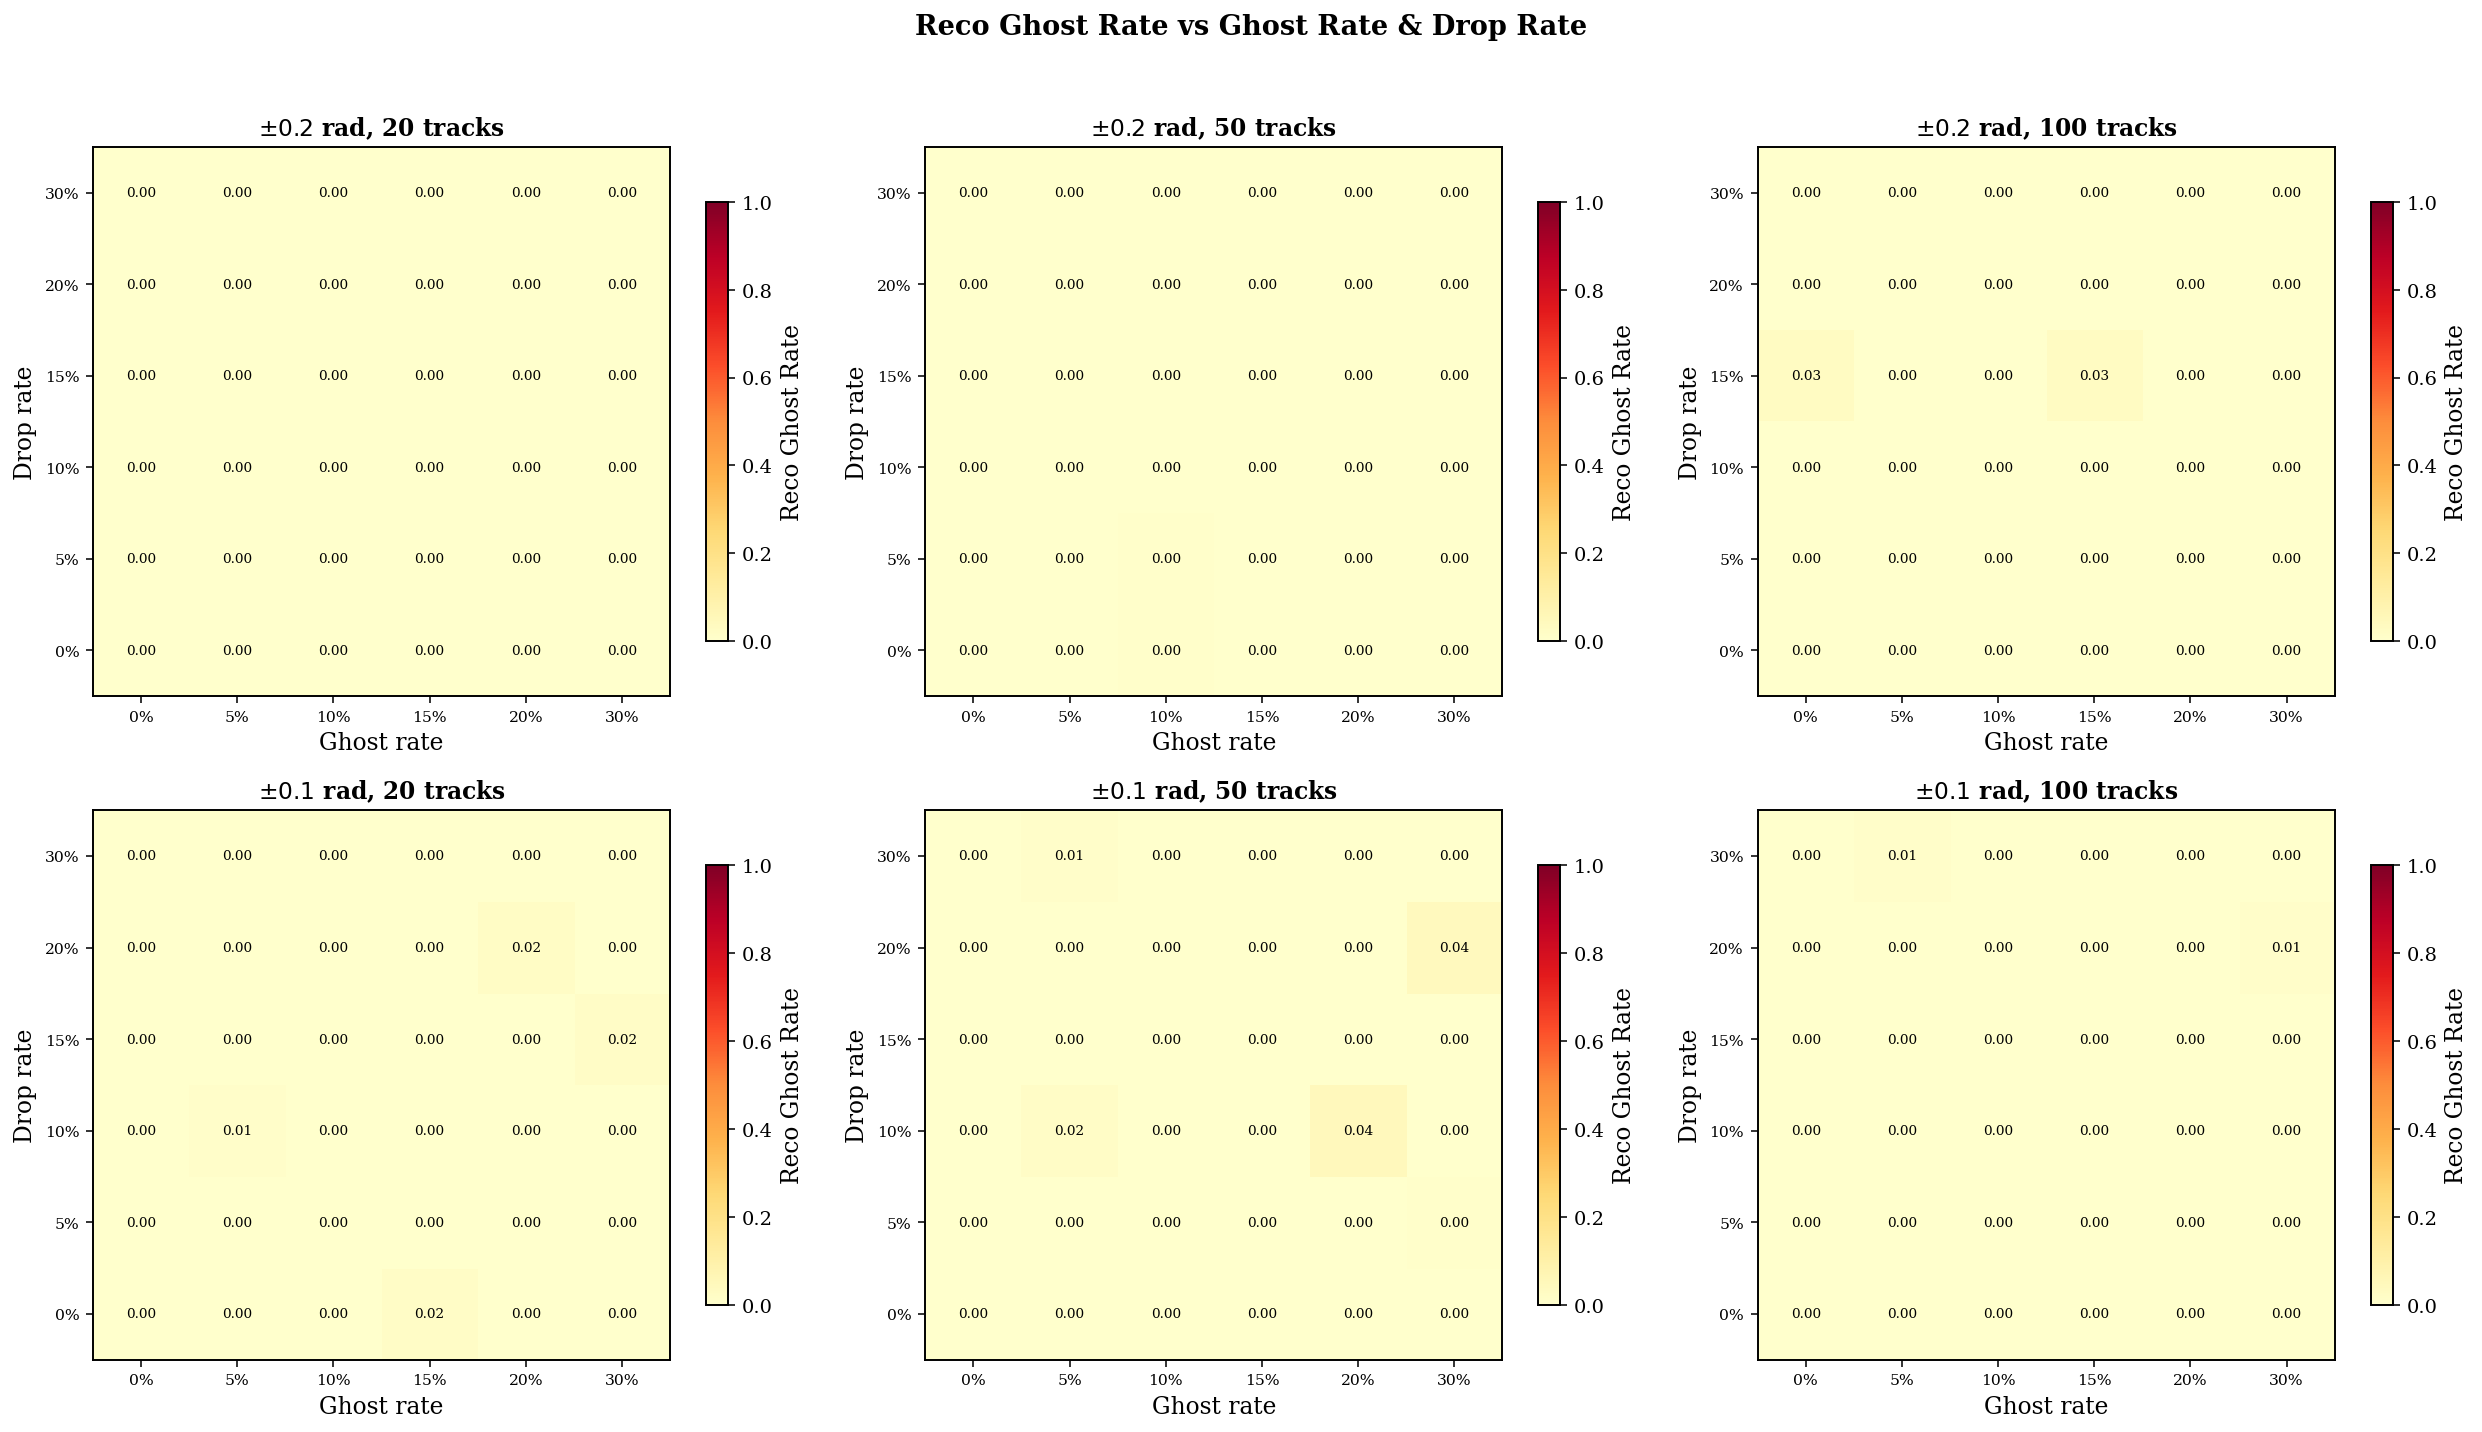

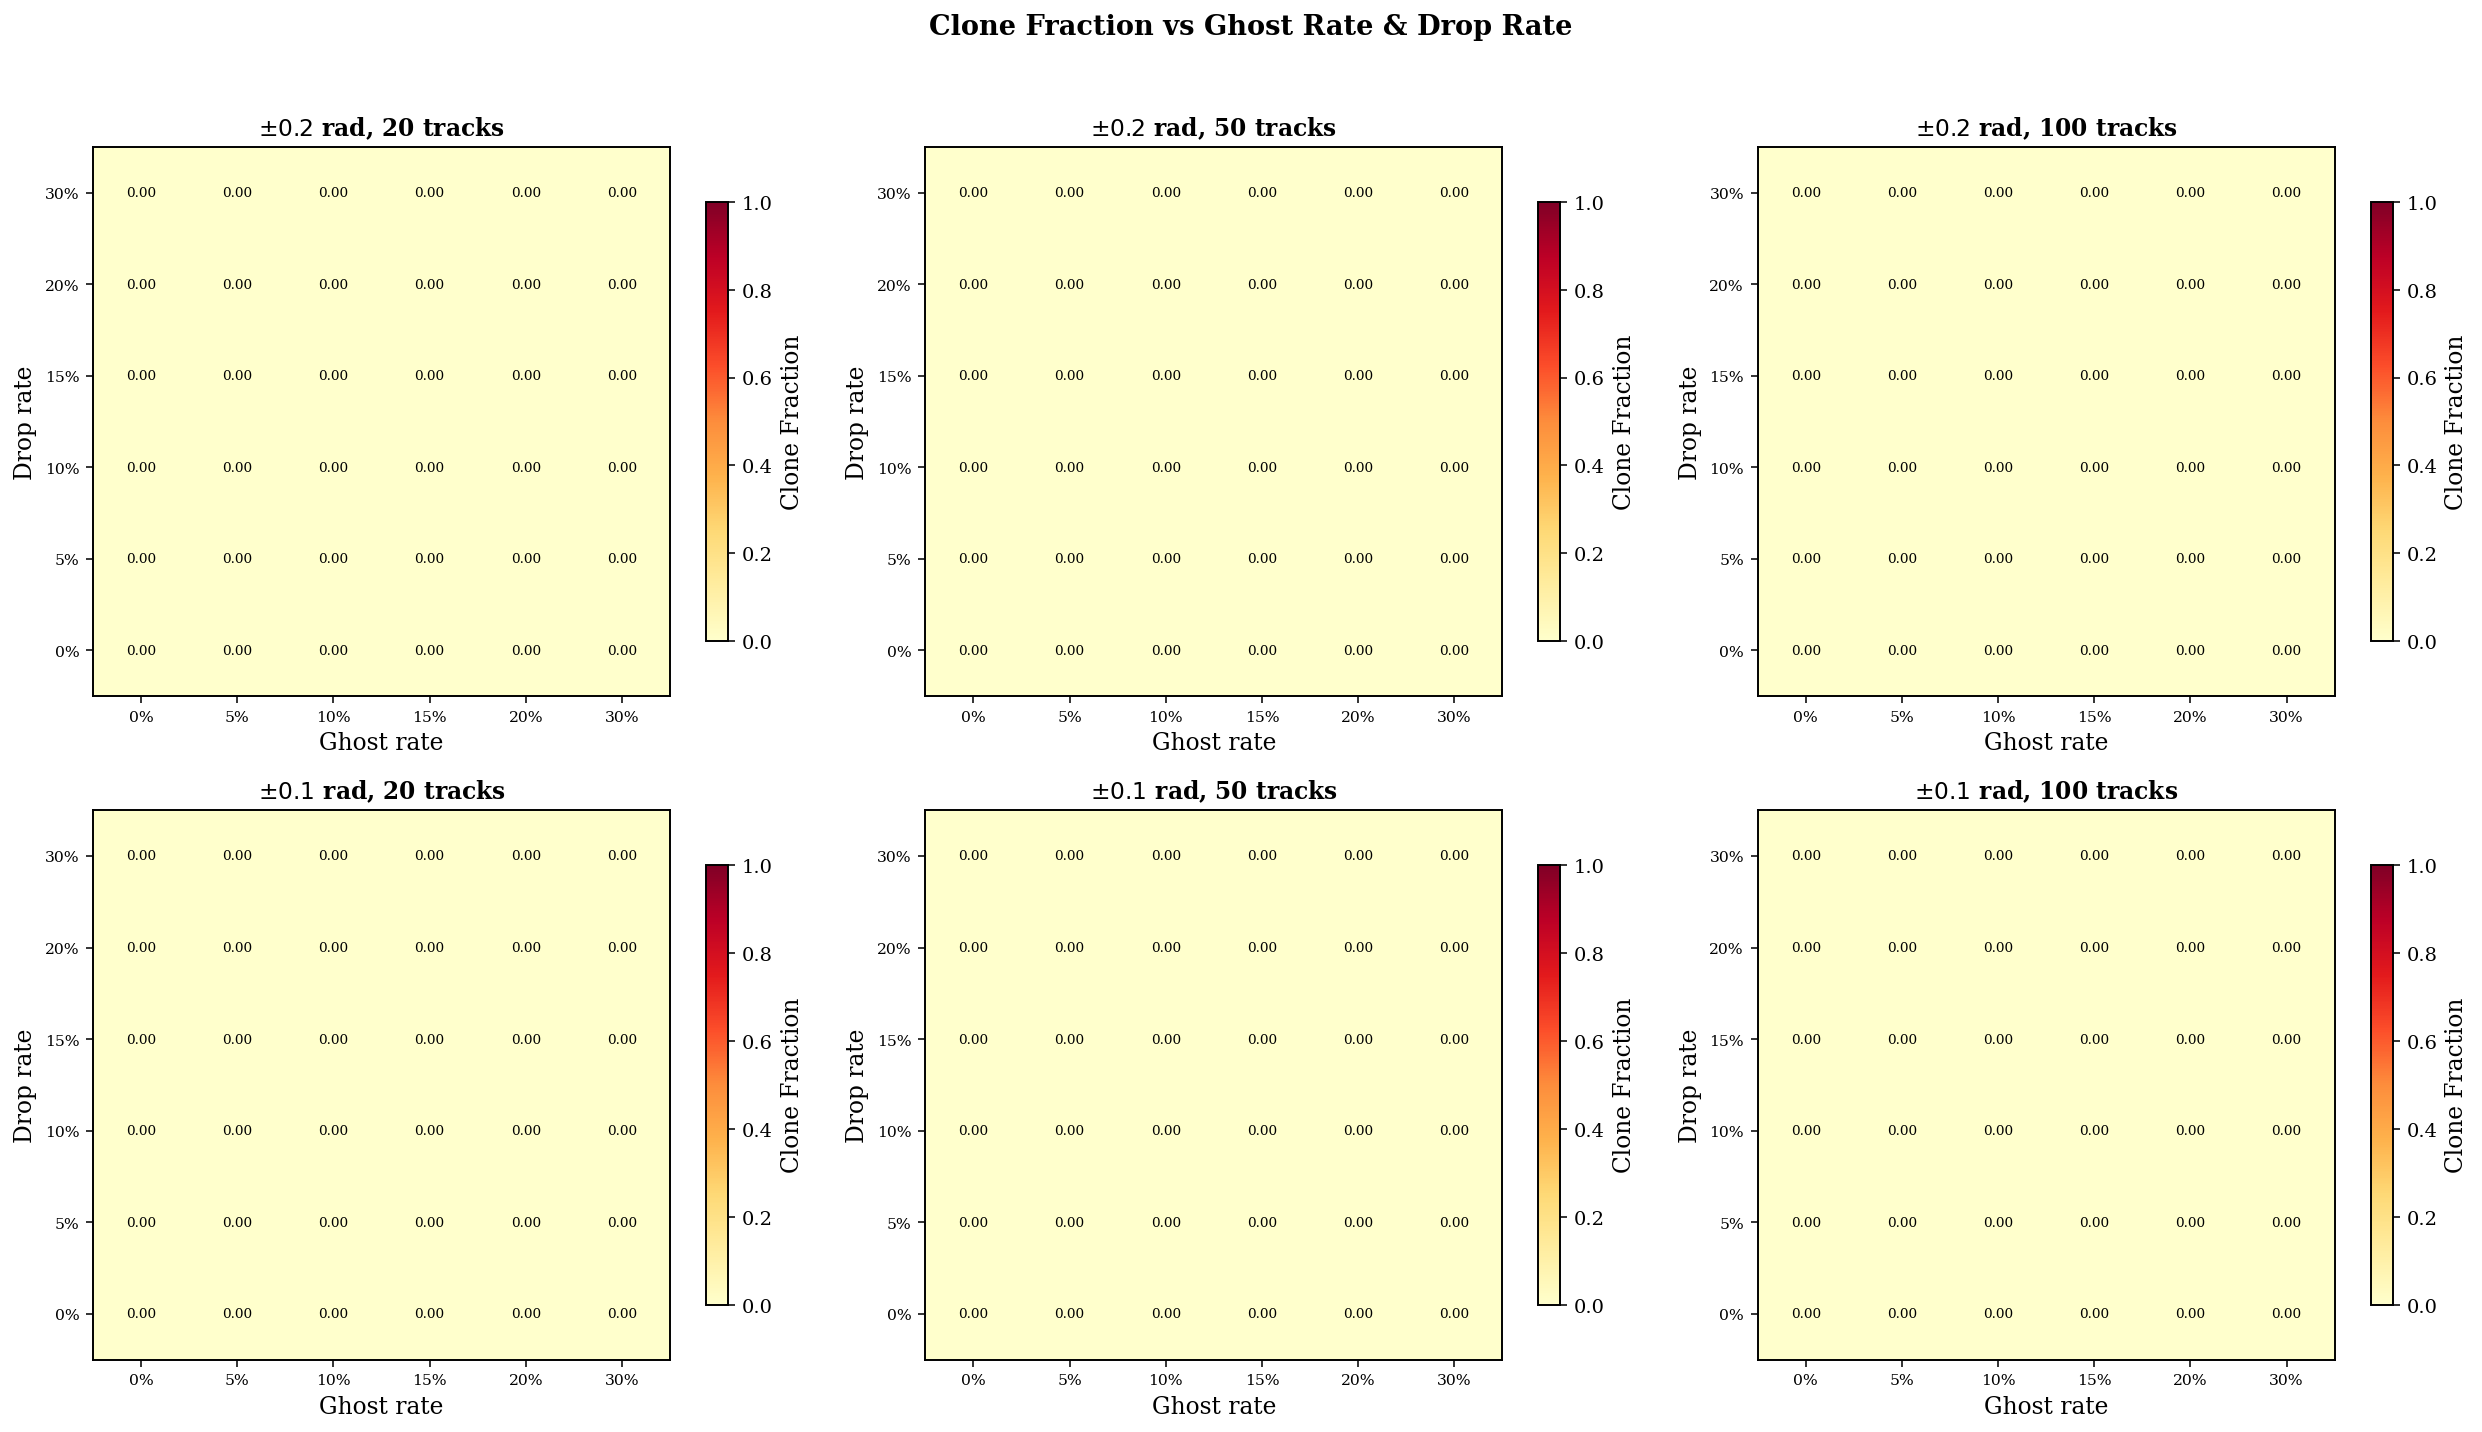

In [47]:
# ── Reconstruction metric heatmaps ──────────────────────────────
reco_metrics = {
    "efficiency":        ("Reconstruction Efficiency",   "RdYlGn",  True),
    "reco_ghost_rate":   ("Reco Ghost Rate",             "YlOrRd",  False),
    "clone_fraction":    ("Clone Fraction",              "YlOrRd",  False),
}

for metric_key, (title, cmap, higher_better) in reco_metrics.items():
    if metric_key not in df.columns:
        print(f"Skipping {metric_key} — not in data")
        continue

    fig, axes = plt.subplots(len(angles), len(track_counts),
                             figsize=(6 * len(track_counts),
                                      5 * len(angles)),
                             squeeze=False)

    for row, angle in enumerate(angles):
        for col, n_trk in enumerate(track_counts):
            ax = axes[row][col]
            sub = df[(df["angle"] == angle) & (df["n_tracks"] == n_trk)]

            piv = sub.pivot_table(
                index="drop_rate", columns="ghost_rate",
                values=metric_key, aggfunc="first")
            piv = piv.reindex(index=drop_rates, columns=ghost_rates)

            im = ax.imshow(piv.values, aspect="auto",
                           cmap=cmap, origin="lower",
                           vmin=0, vmax=1)

            ax.set_xticks(range(len(ghost_rates)))
            ax.set_xticklabels([f"{g:.0%}" for g in ghost_rates], fontsize=8)
            ax.set_yticks(range(len(drop_rates)))
            ax.set_yticklabels([f"{d:.0%}" for d in drop_rates], fontsize=8)
            ax.set_xlabel("Ghost rate")
            ax.set_ylabel("Drop rate")
            ax.set_title(f"$\\pm{angle}$ rad, {n_trk} tracks", fontweight="bold")

            for i in range(len(drop_rates)):
                for j in range(len(ghost_rates)):
                    val = piv.values[i, j]
                    if not np.isnan(val):
                        color = "white" if val > 0.5 else "black"
                        ax.text(j, i, f"{val:.2f}", ha="center",
                                va="center", fontsize=7, color=color)

            plt.colorbar(im, ax=ax, label=title, shrink=0.8)

    plt.suptitle(f"{title} vs Ghost Rate & Drop Rate",
                 fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    save_fig(fig, f"heatmap_{metric_key}")
    plt.show()

## Section 5 — Mean Number of Segments

The total number of segments (true + false) reflects the Hamiltonian size. Ghost hits create extra segments; dropped hits remove some. We track how the mean segment count evolves across the sweep.

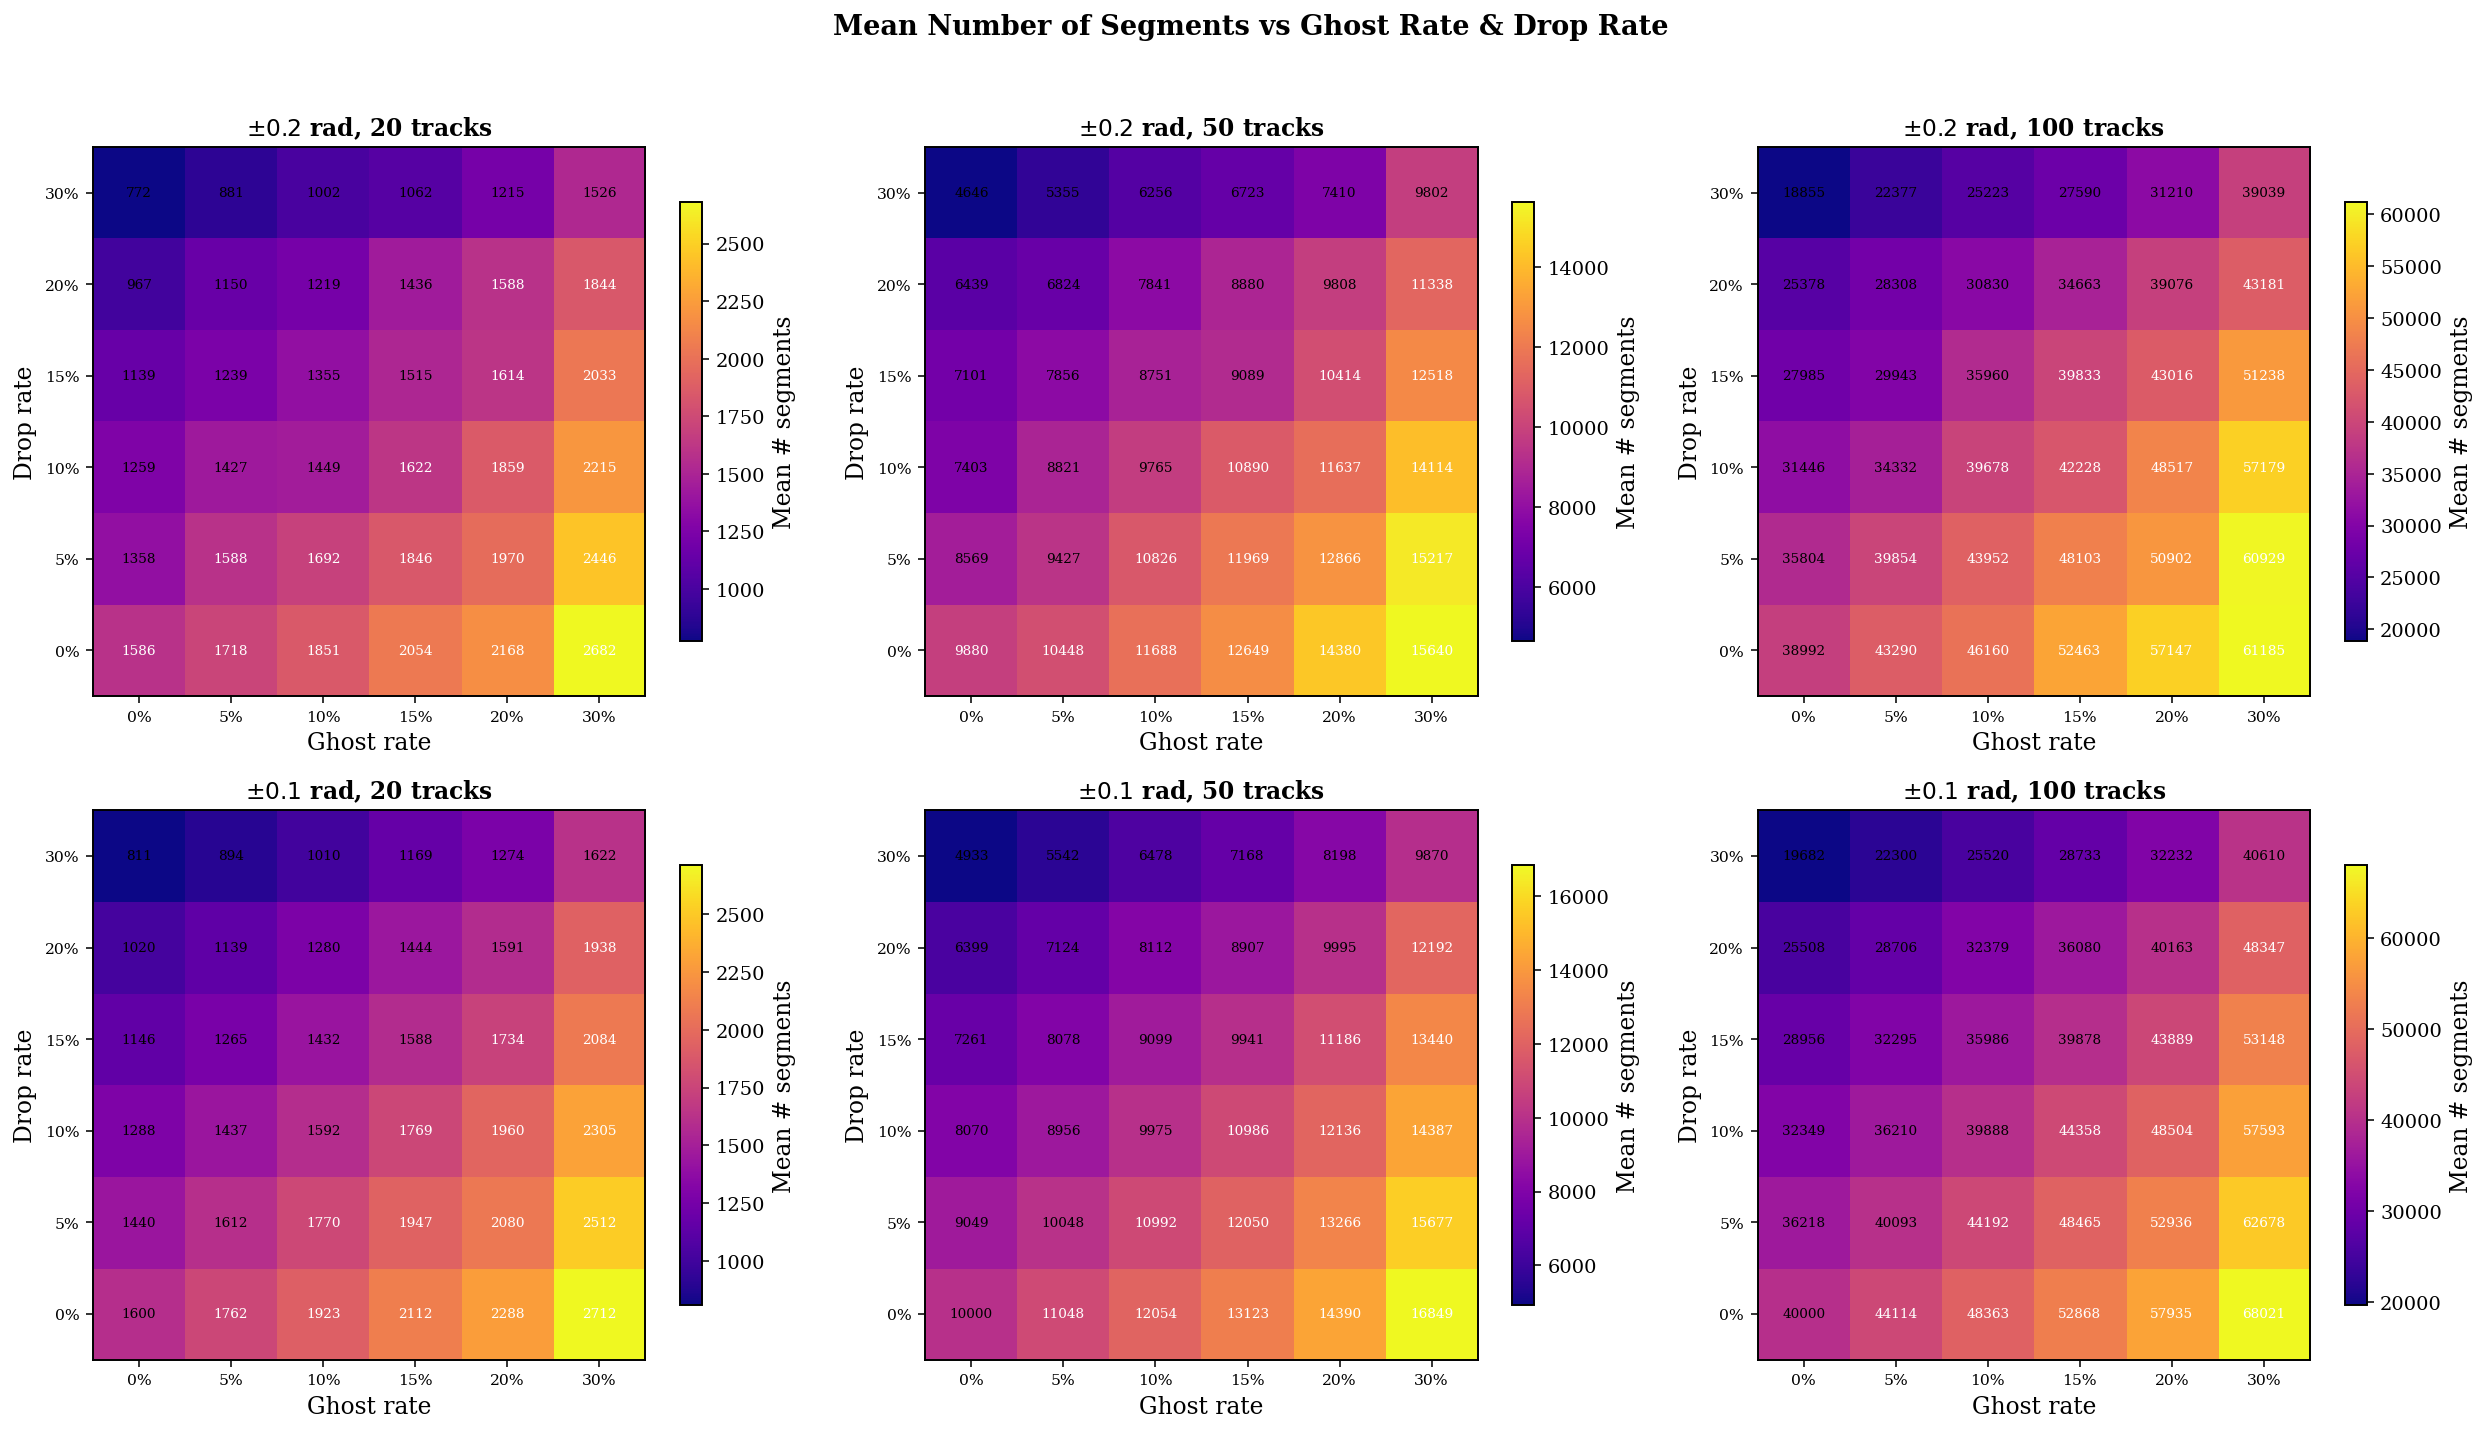

In [48]:
# ── Mean segment count heatmaps ────────────────────────────────
fig, axes = plt.subplots(len(angles), len(track_counts),
                         figsize=(6 * len(track_counts),
                                  5 * len(angles)),
                         squeeze=False)

for row, angle in enumerate(angles):
    for col, n_trk in enumerate(track_counts):
        ax = axes[row][col]
        sub = df[(df["angle"] == angle) & (df["n_tracks"] == n_trk)]

        piv = sub.pivot_table(
            index="drop_rate", columns="ghost_rate",
            values="mean_n_segments", aggfunc="first")
        piv = piv.reindex(index=drop_rates, columns=ghost_rates)

        im = ax.imshow(piv.values, aspect="auto",
                       cmap="plasma", origin="lower")

        ax.set_xticks(range(len(ghost_rates)))
        ax.set_xticklabels([f"{g:.0%}" for g in ghost_rates], fontsize=8)
        ax.set_yticks(range(len(drop_rates)))
        ax.set_yticklabels([f"{d:.0%}" for d in drop_rates], fontsize=8)
        ax.set_xlabel("Ghost rate")
        ax.set_ylabel("Drop rate")
        ax.set_title(f"$\\pm{angle}$ rad, {n_trk} tracks", fontweight="bold")

        for i in range(len(drop_rates)):
            for j in range(len(ghost_rates)):
                val = piv.values[i, j]
                if not np.isnan(val):
                    color = "white" if val > piv.values[~np.isnan(piv.values)].mean() else "black"
                    ax.text(j, i, f"{val:.0f}", ha="center", va="center",
                            fontsize=7, color=color)

        plt.colorbar(im, ax=ax, label="Mean # segments", shrink=0.8)

plt.suptitle("Mean Number of Segments vs Ghost Rate & Drop Rate",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
save_fig(fig, "heatmap_n_segments")
plt.show()

## Section 6 — Activation Spectrum Comparison

Compare the distribution of segment activations between the clean baseline (ghost=0, drop=0) and selected noisy configurations. True segment activations should cluster near 1, while false segments cluster near 0 — noise disrupts this separation.

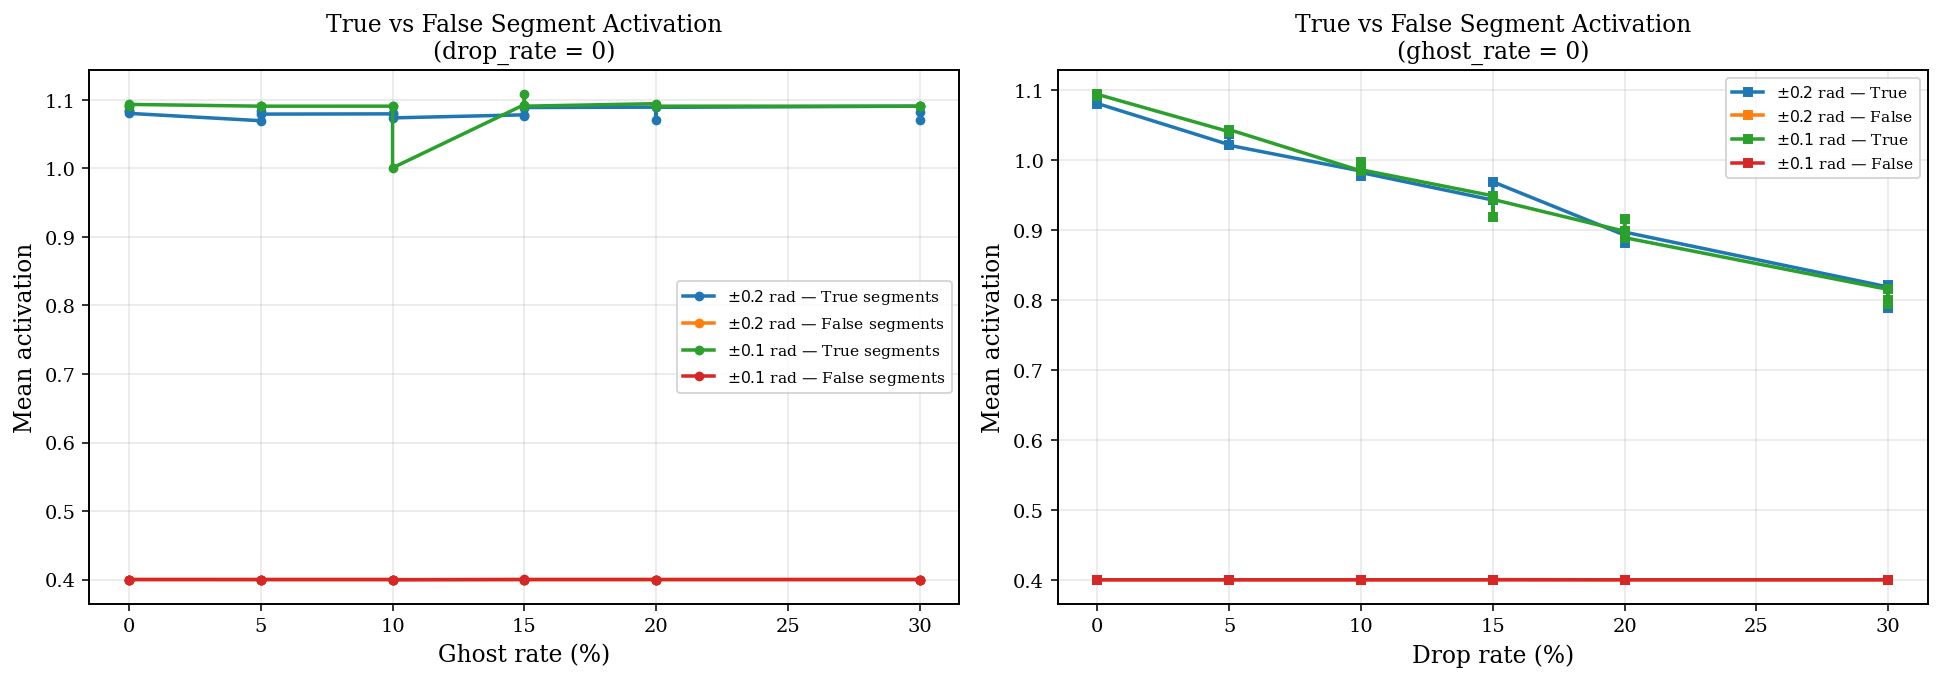

In [49]:
# ── Activation spectrum: mean true vs false activation ──────────
# Compare mean true-segment activation and mean false-segment activation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric_pair, labels in [
    (axes[0],
     ("mean_true_activation", "mean_false_activation"),
     ("True segments", "False segments")),
    (axes[1],
     ("mean_true_activation",),
     ("True segments",)),
]:
    for angle in angles:
        sub = df[(df["angle"] == angle) & (df["drop_rate"] == 0.0)]
        sub = sub.sort_values("ghost_rate")
        for mk, ls, col in zip(metric_pair, labels, ["tab:blue", "tab:red"]):
            if mk not in df.columns:
                continue
            ax.plot(sub["ghost_rate"] * 100, sub[mk],
                    "o-", label=f"$\\pm{angle}$ rad — {ls}",
                    markersize=4)

if "mean_true_activation" in df.columns:
    axes[0].set_xlabel("Ghost rate (%)")
    axes[0].set_ylabel("Mean activation")
    axes[0].set_title("True vs False Segment Activation\n(drop_rate = 0)")
    axes[0].legend(fontsize=8)
    axes[0].grid(True, alpha=0.3)

    # Second panel: true activation vs drop rate at ghost=0
    axes[1].cla()
    for angle in angles:
        sub = df[(df["angle"] == angle) & (df["ghost_rate"] == 0.0)]
        sub = sub.sort_values("drop_rate")
        for mk, ls in [("mean_true_activation", "True"),
                        ("mean_false_activation", "False")]:
            if mk not in df.columns:
                continue
            axes[1].plot(sub["drop_rate"] * 100, sub[mk],
                         "s-", label=f"$\\pm{angle}$ rad — {ls}",
                         markersize=4)
    axes[1].set_xlabel("Drop rate (%)")
    axes[1].set_ylabel("Mean activation")
    axes[1].set_title("True vs False Segment Activation\n(ghost_rate = 0)")
    axes[1].legend(fontsize=8)
    axes[1].grid(True, alpha=0.3)
else:
    for ax in axes:
        ax.text(0.5, 0.5, "Activation data not available",
                transform=ax.transAxes, ha="center", va="center", fontsize=12)

plt.tight_layout()
save_fig(fig, "activation_spectrum")
plt.show()

## Summary

This notebook analyses the systematic sweep over ghost rate and drop rate to characterise the **segment grass** effect:

1. **Anomalous occupancy fraction** — The ±0.2 rad angle consistently shows elevated anomalous occupancy (geometric clipping), while ±0.1 rad remains unaffected. Ghost hits amplify the effect; dropped hits can partially mask it.

2. **Occupancy standard deviation** — Increases with ghost rate (more spurious peaks) and is modulated by drop rate.

3. **Hits-per-module variability** — The coefficient of variation across modules captures the asymmetric hit loss from clipping; ghost hits increase it by padding inner modules more than outer ones.

4. **Reconstruction metrics** — Efficiency degrades with both ghost and drop rates, but ghost hits are more damaging because they create false segments that compete for activation.

5. **Segment count** — Grows quadratically with ghost hits (each ghost hit creates segments with all hits in adjacent modules), while dropped hits have a milder, linear reduction effect.

6. **Activation spectrum** — Ghost hits push false-segment activations upward (closer to the threshold), degrading the clean separation between true and false segments.

### Next steps
- Run the Condor sweep: `cd Segment_Grass && bash submit.sh`
- After jobs finish: `python scripts/aggregate.py`
- Re-run this notebook to populate all figures